# NB3 Fine-tuning PaddleOCR REC pour factures - Promy

- **NB1 Collecte des données** : download Kaggle, inspection structure batch_1/batch_2, inventaire annotations.
- **NB2 Preprocessing** : pipeline image (niveaux de gris via LAB, resize, CLAHE, deskew, denoise), module partagé `preprocessing.py`.
- **NB3 (ce notebook) : Préparation données + Fine-tuning REC + inférence** : parsing annotations, pseudo-labels OCR, split 75/25 anti-leakage par facture, entraînement REC sur crops annotés, export du meilleur checkpoint, tests A/B sur images hors corpus.


## 0. Introduction

**Client** : No Cash No Gain (projet Promy : optimisation du pouvoir d'achat).

**Problème** : extraction automatique de données depuis des factures et catalogues promotionnels pour transformer des documents visuels en données structurées (PostgreSQL / JSON / CSV).

**Contribution du notebook** : fine-tuning de module de reconnaissance (REC) OCR sur 1413 factures Kaggle annotées, export du modèle d'inférence issu du meilleur checkpoint, validation qualitative sur corpus non annoté avec détection avant REC.


### 0.1 Positionnement du modèle retenu

Le choix du modèle retenu s'appuie sur le comparatif consolidé documenté plus en détail dans `NB_Comparatif.ipynb`. On en rappelle ici la logique et les résultats synthétiques avant de dérouler le pipeline OCR REC.

#### Protocole de comparaison

Le comparatif ci-dessous porte sur le **niveau OCR**, c'est-à-dire la capacité à retranscrire correctement une ligne de texte issue d'une facture.
On ne mélange donc pas ici des métriques de transcription (`CER`, `WER`) avec des métriques métier de type extraction de champs.

Les critères retenus pour défendre le choix du modèle sont :
- `CER` et `WER` quand ils sont disponibles sur le même type de corpus
- la taille du modèle
- la latence d'inférence par crop

Pour le détail des hypothèses, du protocole exact et des résultats consolidés, voir `NB_Comparatif.ipynb`.

#### Résultats synthétiques

Ont été évalués sur le même type de corpus factures au niveau de la reconnaissance OCR ligne à ligne :

| Algorithme | Architecture | CER | WER | Paramètres | Latence |
|---|---|---|---|---|---|
| **TrOCR baseline** (pré-entraîné SROIE) | Transformer 12+12 couches | 85.05% | 96.68% | 247M | ~500ms/crop |
| **TrOCR fine-tuné** (Phase 2, dégel -4 ViT) | idem + adaptation domaine | 9.03% | 18.62% | 247M | ~500ms/crop |
| **PaddleOCR REC fine-tuné** (ce notebook) | CRNN (MobileNetV3+BiLSTM+CTC) | **0.19%** | - | **~8M** | **3.39 ms/crop** (batch=12) / 16.4 ms/crop (batch=1), L4 |

**Lecture des métriques.** 
- PaddleOCR REC expose `norm_edit_dis` (distance d'édition normalisée) plutôt que CER directement.
- Le CER proxy est estimé par `1 - norm_edit_dis`. Le meilleur checkpoint retenu (epoch 34) donne `val_norm_edit_dis = 0.9981`, soit un CER proxy de 0.19 % avec une `val_acc` (match exact position par position) de 98.05 %. Cette approximation est conservative et permet une comparaison directe avec le CER HuggingFace utilisé pour TrOCR, en gardant à l'esprit une légère différence de dénominateur (max(|ref|,|pred|) vs |ref|).
- `CER` et `WER` : plus bas = mieux.

**Bilan** :
- **TrOCR baseline** : inutilisable tel quel sur factures, le domain gap reste trop fort.
- **TrOCR fine-tuné** : amélioration nette, mais coût élevé en paramètres et en latence.
- **PaddleOCR REC fine-tuné** : meilleur CER observé (0.19 % vs 9.03 %, soit ~47x moins d'erreurs que TrOCR fine-tuné), ~30x plus léger, beaucoup plus rapide à l'inférence.


### 0.2 Architecture technique du REC

Le module de reconnaissance (PaddleOCR REC) reçoit en entrée une **image de ligne de texte** pas une facture entière. Chaque crop est normalisé au format 32×100 px avant d'être envoyé dans le modèle.

Architecture **CRNN** (Convolutional Recurrent Neural Network) :

1. **Backbone convolutif** : MobileNetV3 extrait une carte de features depuis chaque crop de texte normalisé à 32×100 px.
2. **Tête récurrente** : BiLSTM (2 couches bidirectionnelles) modélise la séquence horizontale des caractères.
3. **Fonction de perte** : CTC (Connectionist Temporal Classification) permet d'aligner la séquence prédite avec la séquence cible sans annotation caractère par caractère.

Architecture légère (~8M paramètres) adaptée aux lignes imprimées homogènes (factures scannées, polices standards). Le CRNN présente ici le meilleur compromis qualité / latence pour une application métier devant traiter de gros volumes de factures.

#### Choix d'architecture : fine-tuner REC seul

Le pipeline étudié dans ce notebook ne fine-tune **que la reconnaissance**. La détection n'est pas réentraînée ici.

| Brique | Rôle | Usage dans ce notebook | Décision |
|---|---|---|---|
| **Teacher de pseudo-labelling** | Produit des boîtes + transcriptions approximatives pour aligner les labels documentaires sur l'image | **RapidOCR** | Choisi pour la préparation des données |
| **Détection locale en tests** | Fournit des boîtes de texte sur facture complète pour les parcours JPG / batch_2 / A/B | **RapidOCR** | Réutilisé tel quel dans les tests locaux |
| **REC PaddleOCR (CRNN)** | Reconnaît les caractères dans chaque crop | **Fine-tuning sur factures** | Cœur du travail d'adaptation domaine |

=> L'adaptation au domaine porte sur le **REC PaddleOCR**. RapidOCR est utilisé comme brique utilitaire de détection / teacher pour bootstraper et tester le pipeline local.
Sur ce corpus de factures, le fine-tuning du module REC seul doit suffire à produire une reconnaissance ligne à ligne exploitable, tout en restant plus léger et plus rapide qu'un modèle transformer plus lourd.

#### Définitions Métriques

- `loss` : CTC loss pendant l'entraînement => mesure l'écart entre distribution prédite et cible ; non interprétable directement comme taux d'erreur.
- `acc` : accuracy PaddleOCR => correspondance exacte position par position entre séquence prédite et référence. Pas de tolérance aux insertions/suppressions. Métrique sévère sur séquences longues.
- `norm_edit_dis` : distance d'édition normalisée (Levenshtein / max(|ref|,|pred|)). Tolère insertions, suppressions et substitutions. Plus robuste que `acc` face aux erreurs localisées.
- `cer_proxy = 1 - norm_edit_dis` : approximation du CER, déduite de la métrique native PaddleOCR. Dénominateur = max(|ref|,|pred|), légèrement différent du CER standard. `acc` et `cer_proxy` ne sont pas identiques : `acc` exige le match exact, `cer_proxy` tolère les décalages par édition.
- `CER` (HuggingFace `evaluate`) : (insertions + substitutions + suppressions) / |ref|. Utilisé pour TrOCR dans NB_Comparatif. La comparaison `cer_proxy` vs `CER` est indicative (légère différence de dénominateur), suffisante pour défendre le choix de modèle.
- `WER` : même formule que CER au niveau mot. Plus volatile : un caractère faux casse un mot entier.
- `latence` et `nombre de paramètres` : critères d'exploitation pour juger la compatibilité avec le MVP.

#### Données

- Source : dataset Kaggle `high-quality-invoice-images-for-ocr`
- Entraînement : batch_1 = 1413 factures annotées ==> ~21K crops (lignes de texte) après pseudo-labelling
- Validation supervisée : split interne 75/25 par facture (anti-leakage)
- Validation qualitative : batch_2 (300 factures, non annoté)

## 1. Imports et configuration


### 1.1 Imports dépendances

In [1]:
# Dépendances (à exécuter une fois si nécessaire)
# Si Paddle n'est pas déjà installé dans l'environnement choisir UNE option:
# 1) GPU (adapter selon la stack CUDA)
# !pip install -q paddlepaddle-gpu==2.6.2.post120 -f https://www.paddlepaddle.org.cn/whl/linux/mkl/avx/stable.html
# 2) CPU
# !pip install -q paddlepaddle==2.6.2

# Dépendances projet
# !pip install -q kagglehub pandas numpy opencv-python pyyaml matplotlib tqdm paddleocr

In [2]:
import ast
import json
import math
import os
import shutil
import random
import re
import subprocess
import sys
from collections import defaultdict
from difflib import SequenceMatcher
from pathlib import Path

try:
    import kagglehub
except ModuleNotFoundError:
    kagglehub = None

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from rapidocr_onnxruntime import RapidOCR
from tqdm.auto import tqdm

print(f"Python: {sys.version.split()[0]}")
print("kagglehub disponible:", kagglehub is not None)


Python: 3.12.13
kagglehub disponible: True


### 1.2 Configuration de base


In [3]:
# Configuration de base : chemins projet, dataset et environnement d'execution
DATASET_SLUG = "osamahosamabdellatif/high-quality-invoice-images-for-ocr"
ALLOW_KAGGLEHUB_FALLBACK = False

NB_DIR = Path.cwd().resolve()
PROJECT_ROOT = NB_DIR.parent if (NB_DIR / "preprocessing.py").exists() else NB_DIR

WORK_DIR = (PROJECT_ROOT / "workspace_paddleocr_invoice").resolve()
PREP_DIR = WORK_DIR / "prepared_data"
RUNS_DIR = WORK_DIR / "runs"
EXPORT_DIR = WORK_DIR / "export"


def detect_gpu_with_nvidia_smi():
    info = {
        "available": False,
        "count": 0,
        "name": None,
        "vram_gb": 0.0,
        "error": None,
    }
    try:
        out = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total",
                "--format=csv,noheader,nounits",
            ],
            text=True,
            stderr=subprocess.STDOUT,
        )
        lines = [ln.strip() for ln in out.splitlines() if ln.strip()]
        if not lines:
            info["error"] = "nvidia-smi retourne une sortie vide"
            return info

        first = [part.strip() for part in lines[0].split(",")]
        if len(first) >= 2:
            info["name"] = first[0]
            try:
                info["vram_gb"] = round(float(first[1]) / 1024.0, 1)
            except Exception:
                info["vram_gb"] = 0.0

        info["available"] = True
        info["count"] = len(lines)
    except Exception as e:
        info["error"] = str(e)
    return info


GPU_INFO = detect_gpu_with_nvidia_smi()
USE_GPU = bool(GPU_INFO["available"])

# Le GPU est pilote explicitement pour les etapes PaddleOCR (train/export/inference REC).
# RapidOCR reste utilise via son backend CPU par defaut pour le pseudo-labeling et la detection locale.
USE_GPU_FOR_FINAL_INFERENCE = USE_GPU

os.environ.setdefault("PADDLE_PDX_CACHE_HOME", "/tmp/paddlex")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK", "True")

TEST_IMAGE = None

for p in [WORK_DIR, PREP_DIR, RUNS_DIR, EXPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("WORK_DIR:", WORK_DIR)
print("USE_GPU (subprocess training):", USE_GPU)
print("USE_GPU_FOR_FINAL_INFERENCE:", USE_GPU_FOR_FINAL_INFERENCE)
print("GPU_INFO:", GPU_INFO)
print("ALLOW_KAGGLEHUB_FALLBACK:", ALLOW_KAGGLEHUB_FALLBACK)
if GPU_INFO.get("error"):
    print("GPU detect note:", GPU_INFO["error"])


PROJECT_ROOT: /teamspace/studios/this_studio
WORK_DIR: /teamspace/studios/this_studio/workspace_paddleocr_invoice
USE_GPU (subprocess training): True
USE_GPU_FOR_FINAL_INFERENCE: True
GPU_INFO: {'available': True, 'count': 1, 'name': 'NVIDIA L4', 'vram_gb': 22.5, 'error': None}
ALLOW_KAGGLEHUB_FALLBACK: False


### 1.3 Import dataset


In [4]:
# Chargement dataset : local en priorité, fallback KaggleHub désactivé par défaut
LOCAL_DATASET_CANDIDATES = [
    (PROJECT_ROOT / "Promy_raw/datasets/High-Quality Invoice Images for OCR").resolve(),
    Path("/home/val/Bureau/Work/Promy_raw/datasets/High-Quality Invoice Images for OCR").resolve(),
    Path.home() / "Promy_raw/datasets/High-Quality Invoice Images for OCR",
    Path("Promy_raw/datasets/High-Quality Invoice Images for OCR").resolve(),
]

dataset_path = None
for candidate in LOCAL_DATASET_CANDIDATES:
    if candidate.exists() and any(candidate.iterdir()):
        dataset_path = candidate.resolve()
        print(f"Dataset local trouvé : {dataset_path}")
        break

if dataset_path is None and ALLOW_KAGGLEHUB_FALLBACK:
    if kagglehub is None:
        raise ModuleNotFoundError(
            "kagglehub n'est pas disponible alors que le fallback KaggleHub est activé."
        )
    print("Aucun dataset local trouvé, fallback KaggleHub...")
    dataset_path = Path(kagglehub.dataset_download(DATASET_SLUG)).resolve()
    print(f"Dataset KaggleHub : {dataset_path}")

if dataset_path is None:
    searched = "\n".join(f"- {p}" for p in LOCAL_DATASET_CANDIDATES)
    raise FileNotFoundError(
        "Dataset local introuvable. NB3 est configuré pour utiliser le dataset Kaggle téléchargé en local. "
        f"Chemins testés:\n{searched}"
    )

print("Dataset path:", dataset_path)


def print_tree(root: Path, max_depth: int = 3, max_entries: int = 120):
    root = root.resolve()
    count = 0
    for p in sorted(root.rglob("*")):
        depth = len(p.relative_to(root).parts)
        if depth > max_depth:
            continue
        print("  " * (depth - 1) + ("- " if depth > 0 else "") + p.name)
        count += 1
        if count >= max_entries:
            print("... (truncated)")
            break


print_tree(dataset_path, max_depth=3, max_entries=60)


Dataset local trouvé : /teamspace/studios/this_studio/Promy_raw/datasets/High-Quality Invoice Images for OCR
Dataset path: /teamspace/studios/this_studio/Promy_raw/datasets/High-Quality Invoice Images for OCR
- batch_1
  - batch_1
    - batch1_1
    - batch1_1.csv
    - batch1_2
    - batch1_2.csv
    - batch1_3
    - batch1_3.csv
- batch_2
  - batch_2
    - batch2_1
    - batch2_2
    - batch2_3
- batch_3
  - batch_1
    - batch1_1
    - batch1_2
    - batch1_3
  - batch_2
    - batch2_1
    - batch2_2
    - batch2_3
  - batch_3
    - batch3_1
    - batch3_2
    - batch3_3
    - batch3_4
    - batch3_5


### 1.4 Paramètres


In [5]:
# Paramètres du run courant
TRAIN_BATCH_NAME = "batch_1"
UNLABELED_VAL_BATCH_NAME = "batch_2"

TRAIN_VAL_SPLIT = 0.75  # train-test split supervise 75/25 sur batch_1
RANDOM_SEED = 42
BATCH2_MAX_IMAGES = 300

FORCE_REBUILD_PREPARED_DATA = False  # False recommandé : réutilise prepared_data si présent ; True => regénère pseudo-labels + crops
RUN_REC_TRAINING = False  # garde-fou: pour ne pas lancer un réentrainement coûteux en temmps sauf si nécessaire
REC_EPOCHS = 40

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("TRAIN_BATCH_NAME:", TRAIN_BATCH_NAME)
print("UNLABELED_VAL_BATCH_NAME:", UNLABELED_VAL_BATCH_NAME)
print("TRAIN_VAL_SPLIT:", TRAIN_VAL_SPLIT)
print("BATCH2_MAX_IMAGES:", BATCH2_MAX_IMAGES)
print("FORCE_REBUILD_PREPARED_DATA:", FORCE_REBUILD_PREPARED_DATA)
print("RUN_REC_TRAINING:", RUN_REC_TRAINING)
print("REC_EPOCHS:", REC_EPOCHS)


TRAIN_BATCH_NAME: batch_1
UNLABELED_VAL_BATCH_NAME: batch_2
TRAIN_VAL_SPLIT: 0.75
BATCH2_MAX_IMAGES: 300
FORCE_REBUILD_PREPARED_DATA: False
RUN_REC_TRAINING: False
REC_EPOCHS: 40


#### Profil entraînement

Ceci est un **profil indicatif** détecté depuis la VRAM pour information mais le **runtime REC retenu pour le run courant** est fixé explicitement plus bas.


In [6]:
# Profil d'entrainement indicatif adapté a la VRAM
# Ce profil sert uniquement de baseline informative ; le runtime REC final est fixé plus bas.
def detect_training_profile(use_gpu: bool, gpu_info: dict):
    cpu_count = os.cpu_count() or 2
    workers = max(2, min(8, cpu_count // 2))

    profile = {
        "device": "gpu" if use_gpu else "cpu",
        "gpu_name": None,
        "vram_gb": 0.0,
        "train_batch_size": 2,
        "eval_batch_size": 2,
        "gradient_accumulation_steps_requested": 8,
        "effective_batch_target": 16,
        "num_workers": min(4, workers),
        "eval_num_workers": min(4, workers),
        "use_amp": False,
        "amp_level": "O2",
        "scale_loss": 1024.0,
    }

    if use_gpu:
        vram_gb = float(gpu_info.get("vram_gb") or 0.0)
        profile.update(
            {
                "gpu_name": gpu_info.get("name"),
                "vram_gb": round(vram_gb, 1),
                "use_amp": True,
                "num_workers": workers,
                "eval_num_workers": workers,
            }
        )

        if vram_gb >= 14:
            train_bs, eval_bs, accum = 8, 8, 2
        elif vram_gb >= 10:
            train_bs, eval_bs, accum = 6, 6, 2
        elif vram_gb >= 7.5:
            train_bs, eval_bs, accum = 4, 4, 4
        else:
            train_bs, eval_bs, accum = 2, 2, 8

        profile.update(
            {
                "train_batch_size": train_bs,
                "eval_batch_size": eval_bs,
                "gradient_accumulation_steps_requested": accum,
                "effective_batch_target": train_bs * accum,
            }
        )

    return profile


TRAINING_PROFILE = detect_training_profile(USE_GPU, GPU_INFO)

print("Profil d'entrainement indicatif detecte")
for key, value in TRAINING_PROFILE.items():
    print(f"  {key}: {value}")

if TRAINING_PROFILE["gradient_accumulation_steps_requested"] > 1:
    print("Note: gradient accumulation reste une cible informative ici (non expose nativement par train.py PaddleOCR).")
print("Note: le runtime REC effectivement utilise est fixe plus bas (batch 256 sur L4).")


Profil d'entrainement indicatif detecte
  device: gpu
  gpu_name: NVIDIA L4
  vram_gb: 22.5
  train_batch_size: 8
  eval_batch_size: 8
  gradient_accumulation_steps_requested: 2
  effective_batch_target: 16
  num_workers: 4
  eval_num_workers: 4
  use_amp: True
  amp_level: O2
  scale_loss: 1024.0
Note: gradient accumulation reste une cible informative ici (non expose nativement par train.py PaddleOCR).
Note: le runtime REC effectivement utilise est fixe plus bas (batch 256 sur L4).


## 2. Préparation des données


#### 2.1 Adaptation au format PaddleOCR

In [7]:
# Helpers dataset / CSV -> format PaddleOCR
# Cette cellule s'occupe uniquement de lire le dataset Kaggle et de reconstruire
# le mapping image -> texte documentaire complet.

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


# --- Normalisation et détection des colonnes CSV ---
def norm_col(s: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(s).lower())


def find_col(cols, candidates):
    nmap = {c: norm_col(c) for c in cols}
    for cand in candidates:
        ncand = norm_col(cand)
        for c, n in nmap.items():
            if n == ncand:
                return c
    for cand in candidates:
        ncand = norm_col(cand)
        for c, n in nmap.items():
            if ncand in n:
                return c
    return None


# --- Localisation des batches et inventaire images ---
def find_batch_root(root: Path, batch_name: str) -> Path:
    candidates = [p for p in root.rglob(batch_name) if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f"Impossible de trouver le dossier '{batch_name}' sous {root}")

    scored = []
    for p in candidates:
        csv_count = len(list(p.glob("*.csv")))
        img_count = sum(1 for f in p.rglob("*") if f.is_file() and f.suffix.lower() in IMAGE_EXTS)
        scored.append((csv_count, img_count, -len(p.parts), p))
    scored.sort(reverse=True)
    return scored[0][-1]


def build_image_lookup(batch_root: Path):
    lookup = {}
    for p in batch_root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            rel = str(p.relative_to(batch_root)).replace("\\", "/").lower()
            lookup.setdefault(rel, p)
            lookup.setdefault(p.name.lower(), p)
    return lookup


def list_images_in_batch(dataset_root: Path, batch_name: str):
    batch_root = find_batch_root(dataset_root, batch_name)
    images = sorted([p for p in batch_root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
    return batch_root, images


# --- Résolution robuste image <-> ligne CSV ---
def resolve_image_path(raw_value, batch_root: Path, image_lookup):
    if pd.isna(raw_value):
        return None
    raw = str(raw_value).strip()
    if not raw:
        return None

    candidates = [raw, raw.replace("\\", "/"), raw.lstrip("./"), Path(raw).name]
    for c in candidates:
        if c.lower() in image_lookup:
            return image_lookup[c.lower()]
    for c in candidates:
        p = (batch_root / c).resolve()
        if p.exists() and p.suffix.lower() in IMAGE_EXTS:
            return p
    stem = Path(raw).stem.lower()
    for _, p in image_lookup.items():
        if p.stem.lower() == stem:
            return p
    return None


# --- Chargement des labels documentaires batch_1 ---
def load_batch_document_labels(dataset_root: Path, batch_name: str):
    batch_root = find_batch_root(dataset_root, batch_name)
    csv_files = sorted(batch_root.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Aucun CSV trouve dans {batch_root}")

    image_lookup = build_image_lookup(batch_root)

    image_col_candidates = ["File Name", "file_name", "filename", "image", "image_path", "img", "path"]
    text_col_candidates = ["OCRed Text", "ocr_text", "text", "label", "transcription", "content"]

    doc_labels = {}
    report = []

    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        cols = list(df.columns)
        image_col = find_col(cols, image_col_candidates)
        text_col = find_col(cols, text_col_candidates)

        if image_col is None or text_col is None:
            raise ValueError(
                f"CSV incompatible: {csv_path.name}\n"
                f"Colonnes trouvees: {cols}\n"
                f"Image col: {image_col} | Text col: {text_col}"
            )

        kept = 0
        for _, row in df.iterrows():
            img_path = resolve_image_path(row.get(image_col), batch_root, image_lookup)
            if img_path is None:
                continue
            text = str(row.get(text_col, "")).strip()
            if not text:
                continue

            key = str(img_path)
            prev = doc_labels.get(key)
            if prev is None or len(text) > len(prev):
                doc_labels[key] = text
            kept += 1

        report.append({"csv": str(csv_path), "rows": len(df), "kept_rows": kept, "columns": cols})

    return batch_root, doc_labels, report


# --- Split train / validation au niveau document ---
def split_document_labels(doc_labels: dict, train_ratio: float, seed: int):
    keys = sorted(doc_labels.keys())
    if len(keys) == 0:
        return {}, {}
    if len(keys) == 1:
        only = keys[0]
        return {only: doc_labels[only]}, {only: doc_labels[only]}

    rng = np.random.default_rng(seed)
    rng.shuffle(keys)

    train_n = int(round(len(keys) * train_ratio))
    train_n = max(1, min(len(keys) - 1, train_n))

    train_keys = keys[:train_n]
    val_keys = keys[train_n:]

    train_docs = {k: doc_labels[k] for k in train_keys}
    val_docs = {k: doc_labels[k] for k in val_keys}
    return train_docs, val_docs


#### 2.2 Génération des pseudo-labels via teacher OCR

Cette étape transforme les labels documentaires `image -> texte complet` en pseudo-annotations ligne par ligne à l'aide de **RapidOCR**.

Dans ce notebook, RapidOCR est utilisé via son backend par défaut pour le pseudo-labeling. Conformément à la documentation RapidOCR, ce mode CPU constitue le mode recommandé de départ. Le GPU est réservé ici aux étapes PaddleOCR effectivement pilotées : entraînement, export et inférence du REC.


In [8]:
# Helpers pseudo-labeling
# Cette cellule ne fait pas encore tourner le pipeline sur le dataset :
# elle définit uniquement la logique de génération des pseudo-annotations.


def doc_similarity(a: str, b: str) -> float:
    a = (a or "").strip().lower()
    b = (b or "").strip().lower()
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return float(SequenceMatcher(None, a, b).ratio())


def build_pseudo_annotations_from_teacher(doc_labels: dict):
    # RapidOCR est utilisé comme teacher léger pour proposer boîtes + transcriptions.
    teacher = RapidOCR()

    by_image = {}
    quality_rows = []

    for img_path, gt_text in tqdm(doc_labels.items(), desc="Pseudo-labeling with RapidOCR"):
        result, _ = teacher(str(img_path))

        anns = []
        pred_texts = []
        confs = []

        for item in result or []:
            if not item or len(item) < 3:
                continue
            box = item[0]
            text = str(item[1]).strip()
            score = float(item[2]) if item[2] is not None else np.nan

            if not text:
                continue

            pts = []
            if isinstance(box, (list, tuple)) and len(box) >= 4:
                for p in box[:4]:
                    try:
                        pts.append([float(p[0]), float(p[1])])
                    except Exception:
                        pts = []
                        break

            if len(pts) != 4:
                continue

            anns.append({"transcription": text, "points": pts, "difficult": False})
            pred_texts.append(text)
            confs.append(score)

        if len(anns) > 0:
            by_image[str(img_path)] = anns

        pred_doc = " ".join(pred_texts)
        quality_rows.append(
            {
                "image_path": str(img_path),
                "n_boxes": len(anns),
                "mean_conf": float(np.nanmean(confs)) if len(confs) > 0 else np.nan,
                "gt_chars": len(gt_text),
                "pred_chars": len(pred_doc),
                "doc_similarity": doc_similarity(gt_text, pred_doc),
            }
        )

    quality_df = pd.DataFrame(quality_rows)
    return by_image, quality_df


#### 2.3 Écriture des jeux DET / REC

Cette étape convertit les pseudo-annotations en fichiers exploités par PaddleOCR : format **DET** puis crops + labels **REC**.


In [9]:
# Helpers export DET / REC
# Cette cellule transforme les pseudo-annotations intermédiaires en artefacts sur disque.


def save_det_labels(by_image: dict, output_file: Path):
    output_file.parent.mkdir(parents=True, exist_ok=True)
    with output_file.open("w", encoding="utf-8") as f:
        for img_path, anns in by_image.items():
            payload = json.dumps(anns, ensure_ascii=False)
            f.write(f"{img_path}\t{payload}\n")


def crop_by_quad(img, pts):
    pts = np.array(pts, dtype=np.float32)
    if pts.shape != (4, 2):
        return None

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).reshape(-1)
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]
    rect = np.array([tl, tr, br, bl], dtype=np.float32)

    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    max_w = int(max(width_a, width_b))
    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_h = int(max(height_a, height_b))

    if max_w < 2 or max_h < 2:
        return None

    dst = np.array([[0, 0], [max_w - 1, 0], [max_w - 1, max_h - 1], [0, max_h - 1]], dtype=np.float32)
    m = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(img, m, (max_w, max_h), flags=cv2.INTER_CUBIC)

    if warped.shape[0] > warped.shape[1] * 1.5:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)
    return warped


def save_rec_dataset(by_image: dict, rec_img_dir: Path, rec_label_file: Path, prefix: str):
    rec_img_dir.mkdir(parents=True, exist_ok=True)
    rec_label_file.parent.mkdir(parents=True, exist_ok=True)

    lines = []
    sample_idx = 0
    for img_path, anns in tqdm(by_image.items(), desc=f"Generate rec crops ({prefix})"):
        img = cv2.imread(img_path)
        if img is None:
            continue
        for ann in anns:
            text = str(ann.get("transcription", "")).strip()
            pts = ann.get("points")
            if not text or pts is None:
                continue
            crop = crop_by_quad(img, pts)
            if crop is None:
                continue
            out_name = f"{prefix}_{sample_idx:07d}.jpg"
            out_path = rec_img_dir / out_name
            cv2.imwrite(str(out_path), crop)
            safe_text = text.replace("\t", " ").replace("\n", " ")
            lines.append(f"{out_path}\t{safe_text}\n")
            sample_idx += 1

    with rec_label_file.open("w", encoding="utf-8") as f:
        f.writelines(lines)

    return len(lines)


#### 2.4 Orchestration

Cette cellule orchestre le workflow complet : chargement dataset, split, réutilisation éventuelle du cache `prepared_data`, génération des pseudo-labels via **RapidOCR CPU**, puis écriture des fichiers DET / REC.


In [10]:
# Orchestration complète : split, cache, pseudo-labeling, puis export DET / REC
batch1_root, batch1_doc_labels, batch1_report = load_batch_document_labels(dataset_path, TRAIN_BATCH_NAME)
train_docs, val_docs = split_document_labels(batch1_doc_labels, TRAIN_VAL_SPLIT, RANDOM_SEED)

# batch_2 est réservé à la validation qualitative non annotée en fin de notebook
batch2_root, batch2_images = list_images_in_batch(dataset_path, UNLABELED_VAL_BATCH_NAME)

print("Batch1 root:", batch1_root)
print("Batch2 root:", batch2_root)
print("Batch1 docs labels (total):", len(batch1_doc_labels))
print("Train docs:", len(train_docs))
print("Val docs (split interne):", len(val_docs))
print("Batch2 images non annotees:", len(batch2_images))

print("\nBatch1 CSV report:")
for r in batch1_report:
    print(f"- {Path(r['csv']).name}: rows={r['rows']}, kept={r['kept_rows']}")

if len(train_docs) == 0 or len(val_docs) == 0:
    raise RuntimeError("Split supervise vide. Verifie les labels batch_1.")

train_quality_csv = PREP_DIR / "pseudo_quality_train.csv"
val_quality_csv = PREP_DIR / "pseudo_quality_val.csv"

train_det_label = PREP_DIR / "train_det.txt"
val_det_label = PREP_DIR / "val_det.txt"
train_rec_label = PREP_DIR / "train_rec.txt"
val_rec_label = PREP_DIR / "val_rec.txt"

batch2_list_file = PREP_DIR / "batch2_unlabeled_images.txt"
batch2_list_file.write_text("\n".join(str(p) for p in batch2_images), encoding="utf-8")


def count_non_empty_lines(path: Path) -> int:
    if not path.exists():
        return 0
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        return sum(1 for ln in f if ln.strip())


# Si les artefacts préparés existent déjà, on les réutilise pour éviter de régénérer
# les pseudo-labels et les crops REC.
prepared_cache_ready = all(
    p.exists()
    for p in [train_quality_csv, val_quality_csv, train_det_label, val_det_label, train_rec_label, val_rec_label]
)
prepared_cache_ready = prepared_cache_ready and count_non_empty_lines(train_det_label) > 0 and count_non_empty_lines(train_rec_label) > 0

if prepared_cache_ready and (not FORCE_REBUILD_PREPARED_DATA):
    print("\nCache prepare_data detecte -> on saute la generation des pseudo-labels.")
    print("(Mettre FORCE_REBUILD_PREPARED_DATA=True pour regenerer)")

    train_quality = pd.read_csv(train_quality_csv)
    val_quality = pd.read_csv(val_quality_csv)

    TRAIN_DET_IMAGES_COUNT = count_non_empty_lines(train_det_label)
    VAL_DET_IMAGES_COUNT = count_non_empty_lines(val_det_label)
    train_rec_count = count_non_empty_lines(train_rec_label)
    val_rec_count = count_non_empty_lines(val_rec_label)

    train_by_image = {}
    val_by_image = {}
elif not RUN_REC_TRAINING:
    print("\nCache prepare_data absent mais RUN_REC_TRAINING=False -> on ne regenere pas les pseudo-labels.")
    print("La reprise courante n'a besoin que de batch_2 et des tests d'inférence locale.")

    train_quality = pd.DataFrame()
    val_quality = pd.DataFrame()
    train_by_image = {}
    val_by_image = {}
    TRAIN_DET_IMAGES_COUNT = 0
    VAL_DET_IMAGES_COUNT = 0
    train_rec_count = 0
    val_rec_count = 0
else:
    # Génération effective des pseudo-labels
    print("\nGeneration des pseudo labels via teacher OCR...")
    print("Teacher OCR engine: RapidOCR (mode=cpu, default recommended)")

    train_by_image, train_quality = build_pseudo_annotations_from_teacher(train_docs)
    val_by_image, val_quality = build_pseudo_annotations_from_teacher(val_docs)

    print("Pseudo labels train images:", len(train_by_image))
    print("Pseudo labels val images:", len(val_by_image))
    print("Train similarity moyenne:", train_quality['doc_similarity'].mean() if len(train_quality) else float('nan'))
    print("Val similarity moyenne:", val_quality['doc_similarity'].mean() if len(val_quality) else float('nan'))

    if len(train_by_image) == 0 or len(val_by_image) == 0:
        raise RuntimeError("Aucun pseudo label généré. Vérifier le teacher OCR / environnement GPU.")

    # Sauvegarde de la qualité du pseudo-labeling
    train_quality.to_csv(train_quality_csv, index=False)
    val_quality.to_csv(val_quality_csv, index=False)

    # Fichiers DET : boîtes + texte par image, au format attendu par PaddleOCR.
    save_det_labels(train_by_image, train_det_label)
    save_det_labels(val_by_image, val_det_label)

    # Fichiers REC : génération des crops de lignes et du fichier de labels associé.
    train_rec_count = save_rec_dataset(train_by_image, PREP_DIR / "rec_images" / "train", train_rec_label, "train")
    val_rec_count = save_rec_dataset(val_by_image, PREP_DIR / "rec_images" / "val", val_rec_label, "val")

    TRAIN_DET_IMAGES_COUNT = len(train_by_image)
    VAL_DET_IMAGES_COUNT = len(val_by_image)

print("\nFichiers utilisés/générés:")
print("-", train_det_label, "(images=", TRAIN_DET_IMAGES_COUNT, ")")
print("-", val_det_label, "(images=", VAL_DET_IMAGES_COUNT, ")")
print("-", train_rec_label, "(samples=", train_rec_count, ")")
print("-", val_rec_label, "(samples=", val_rec_count, ")")
print("-", train_quality_csv)
print("-", val_quality_csv)
print("-", batch2_list_file)

if RUN_REC_TRAINING and (train_rec_count == 0 or val_rec_count == 0):
    raise RuntimeError("Le dataset rec est vide après crop. Vérifier la génération des pseudo labels.")


Batch1 root: /teamspace/studios/this_studio/Promy_raw/datasets/High-Quality Invoice Images for OCR/batch_1/batch_1
Batch2 root: /teamspace/studios/this_studio/Promy_raw/datasets/High-Quality Invoice Images for OCR/batch_2
Batch1 docs labels (total): 1413
Train docs: 1060
Val docs (split interne): 353
Batch2 images non annotees: 1491

Batch1 CSV report:
- batch1_1.csv: rows=499, kept=499
- batch1_2.csv: rows=426, kept=426
- batch1_3.csv: rows=489, kept=489

Cache prepare_data detecte -> on saute la generation des pseudo-labels.
(Mettre FORCE_REBUILD_PREPARED_DATA=True pour regenerer)

Fichiers utilisés/générés:
- /teamspace/studios/this_studio/workspace_paddleocr_invoice/prepared_data/train_det.txt (images= 1060 )
- /teamspace/studios/this_studio/workspace_paddleocr_invoice/prepared_data/val_det.txt (images= 353 )
- /teamspace/studios/this_studio/workspace_paddleocr_invoice/prepared_data/train_rec.txt (samples= 79821 )
- /teamspace/studios/this_studio/workspace_paddleocr_invoice/prepare

#### 2.5 Choix du DET, qualité des pseudo-labels, méthode et limites

**Source des pseudo-labels.**

Le dataset Kaggle fournit des annotations documentaires (`image → texte complet de la facture`) pas des annotations ligne par ligne. Le pipeline de préparation utilise RapidOCR comme teacher pour :      
1. détecter les zones texte (bounding boxes) ;
2. reconnaître le texte dans chaque zone ;
3. aligner chaque crop reconnu sur le label documentaire via similarité de séquence (`SequenceMatcher`, `doc_similarity`).

**Pourquoi RapidOCR plutôt que PaddleOCR DET ?**

Le détecteur de RapidOCR est un export ONNX du DBNet PP-OCR, soit la même architecture que celle embarquée par PaddleOCR. Un mini-benchmark dédié (`NB_DET_Benchmark.ipynb`, 20 factures du jeu train) confirme cette équivalence :

- Même nombre de boîtes produites par image sur les 20 images testées (1462 boîtes au total pour les deux détecteurs).
- Match rate à IoU >= 0.5 de 100 % dans les deux sens ; IoU best-match médiane de 0.75.
- Seule différence mesurable : PaddleOCR applique un `unclip_ratio` plus large et produit des crops ~18-20 % plus paddés. RapidOCR produit des crops plus serrés autour du texte.
- Latence de détection ~9× plus rapide côté RapidOCR sur CPU via ONNX Runtime.

Ce choix a trois conséquences retenues pour le pipeline :

1. **Qualité de détection équivalente** : aucune raison qualitative de préférer PaddleOCR DET.
2. **Cohérence train/infer du REC** : les crops d'entraînement et les crops d'inférence sont générés par le même détecteur avec le même cadrage serré. Changer de DET à l'inférence par exemple enverrait au REC des crops avec plus de contexte que ce qu'il a appris à consommer, soit un distribution shift à éviter.
3. **Coût opérationnel** : RapidOCR évite d'instancier un second runtime Paddle pour le teacher offline et pour la détection à l'inférence locale (§9).

**Bruit des pseudo-labels.** Les pseudo-labels ne sont pas des annotations manuelles. Ils héritent des erreurs RapidOCR (mauvaise segmentation, reconnaissance imparfaite sur les lignes difficiles). Un crop dont la reconnaissance RapidOCR est trop éloignée du label documentaire peut recevoir un label imprécis ou être filtré.

**Mitigation.** La fonction `doc_similarity` (ratio Levenshtein sur l'ensemble du document) écarte les crops dont l'alignement est trop faible. Le cache `prepared_data` permet de vérifier a posteriori la distribution des scores de similarité si nécessaire.

**Limites assumées.**

- Absence d'annotation manuelle : choix délibéré (Kaggle fournit un ground truth documentaire exploitable) mais plafond de qualité sur les labels les plus bruités.
- Pas de ground truth de boîtes : le benchmark DET mesure l'accord entre détecteurs, pas leur justesse absolue.
- Pourrait-on gagner en généralisation en ré-entraînant le REC sur des crops PaddleOCR DET (plus paddés, effet data augmentation soft) ? Hypothèse non testée ici.
Arbitrage : gain attendu faible (REC déjà à CER proxy 0.19 %).
- Levier plus rentable si besoin de robustesse au cadrage : activer les augmentations REC natives PaddleOCR (RandomCrop, RecAug) plutôt que changer de DET teacher.

## 3. Setup REC PaddleOCR


In [11]:
# Setup repo PaddleOCR local
PADDLEOCR_REPO_CANDIDATES = [
    (WORK_DIR / "PaddleOCR").resolve(),
    WORK_DIR.resolve(),
]

PADDLEOCR_REPO = None
for candidate in PADDLEOCR_REPO_CANDIDATES:
    if (
        (candidate / "tools/infer/predict_system.py").exists()
        and (candidate / "configs/rec").exists()
    ):
        PADDLEOCR_REPO = candidate
        break

if PADDLEOCR_REPO is None:
    searched = "\n".join(f"- {p}" for p in PADDLEOCR_REPO_CANDIDATES)
    raise FileNotFoundError(
        "Repo PaddleOCR introuvable sous workspace_paddleocr_invoice. "
        f"Chemins testés:\n{searched}"
    )

print("PaddleOCR repo:", PADDLEOCR_REPO)
print("predict_system.py:", PADDLEOCR_REPO / "tools/infer/predict_system.py")


PaddleOCR repo: /teamspace/studios/this_studio/workspace_paddleocr_invoice
predict_system.py: /teamspace/studios/this_studio/workspace_paddleocr_invoice/tools/infer/predict_system.py


### Chargement de la configuration REC PaddleOCR


In [12]:
# Ce notebook configure uniquement le REC PaddleOCR.
# La détection locale reste assurée par RapidOCR dans les parcours de test.

def pick_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


# REC configuration retenue pour l'expérience
REC_CFG = PADDLEOCR_REPO / "configs/rec/rec_mv3_none_bilstm_ctc.yml"
if not REC_CFG.exists():
    raise FileNotFoundError(f"Config REC introuvable: {REC_CFG}")

print("REC_CFG:", REC_CFG)


# Dictionnaire de caractères REC
dict_candidates = [
    PADDLEOCR_REPO / "ppocr/utils/en_dict.txt",
    PADDLEOCR_REPO / "ppocr/utils/dict/en_dict.txt",
]
CHAR_DICT = pick_first_existing(dict_candidates)
print("CHAR_DICT:", CHAR_DICT)


# Checkpoint officiel REC compatible avec rec_mv3_none_bilstm_ctc.yml
# Sert de point de départ au fine-tuning ; si absent, l'entraînement part from scratch.
REC_PRETRAINED = (
    PADDLEOCR_REPO
    / "pretrain_models"
    / "rec_mv3_none_bilstm_ctc_v2.0_train"
    / "best_accuracy"
)

print("REC_PRETRAINED candidate:", REC_PRETRAINED)
print("REC_PRETRAINED .pdparams exists:", REC_PRETRAINED.with_suffix(".pdparams").exists())

if REC_PRETRAINED.with_suffix(".pdparams").exists():
    REC_PRETRAINED = str(REC_PRETRAINED)
    print("REC pretrained found:", REC_PRETRAINED)
else:
    REC_PRETRAINED = None
    print("REC pretrained missing -> train from scratch")


REC_CFG: /teamspace/studios/this_studio/workspace_paddleocr_invoice/configs/rec/rec_mv3_none_bilstm_ctc.yml
CHAR_DICT: /teamspace/studios/this_studio/workspace_paddleocr_invoice/ppocr/utils/en_dict.txt
REC_PRETRAINED candidate: /teamspace/studios/this_studio/workspace_paddleocr_invoice/pretrain_models/rec_mv3_none_bilstm_ctc_v2.0_train/best_accuracy
REC_PRETRAINED .pdparams exists: True
REC pretrained found: /teamspace/studios/this_studio/workspace_paddleocr_invoice/pretrain_models/rec_mv3_none_bilstm_ctc_v2.0_train/best_accuracy


## 4. Métriques & suivi d'entraînement

Cette section configure les hyperparamètres de suivi d'entraînement :

- `REC_TRAIN_BATCH` / `REC_EVAL_BATCH` : tailles de batch **retenues pour le run courant** (`256`) après validation empirique sur GPU L4.
- `REC_TRAIN_NUM_WORKERS` / `REC_EVAL_NUM_WORKERS` : nombre de workers I/O pour les DataLoaders train et validation.
- `REC_EVAL_EVERY` : cadence d'évaluation en steps ; ici elle est alignée sur **1 epoch**, ce qui produit une mesure de validation à chaque epoch.
- `USE_AMP` / `AMP_LEVEL` : précision mixte (fp16) pour réduire la consommation mémoire sans perte de qualité.
- `LIVE_METRICS_CALLBACK` / `LIVE_METRICS_PLOT_EVERY_EPOCH` : callback de visualisation live des métriques epoch par epoch.


In [13]:
# Suivi des metriques d'entrainement par epoch (avec callback visuel live)
plt.style.use("seaborn-v0_8-darkgrid")

METRICS_DIR = RUNS_DIR / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Callback live pendant l'entrainement
LIVE_METRICS_CALLBACK = True
LIVE_METRICS_PLOT_EVERY_EPOCH = 1
LIVE_METRICS_SHOW_TABLE_ROWS = 8

FLOAT_RE = r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?"
EPOCH_RE = re.compile(r"epoch[^0-9]*(\d+)", re.I)
LOSS_RE = re.compile(r"\bloss\b[:=\s]*(" + FLOAT_RE + r")", re.I)
ACC_RE = re.compile(r"\bacc\b[:=\s]*(" + FLOAT_RE + r")", re.I)
NORM_EDIT_RE = re.compile(r"\bnorm_edit_dis\b[:=\s]*(" + FLOAT_RE + r")", re.I)
PRECISION_RE = re.compile(r"\bprecision\b[:=\s]*(" + FLOAT_RE + r")", re.I)
RECALL_RE = re.compile(r"\brecall\b[:=\s]*(" + FLOAT_RE + r")", re.I)
HMEAN_RE = re.compile(r"\bhmean\b[:=\s]*(" + FLOAT_RE + r")", re.I)


def find_first_int_recursive(obj, keys):
    if isinstance(obj, dict):
        for k in keys:
            v = obj.get(k)
            if isinstance(v, int):
                return int(v)
        for v in obj.values():
            found = find_first_int_recursive(v, keys)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for item in obj:
            found = find_first_int_recursive(item, keys)
            if found is not None:
                return found
    return None


def get_batch_size_from_cfg(cfg_path: Path) -> int | None:
    data = yaml.safe_load(cfg_path.read_text(encoding="utf-8"))
    return find_first_int_recursive(data, {"batch_size_per_card", "batch_size", "batch_size_per_gpu"})


def compute_eval_every(train_count: int, batch_size: int | None) -> int:
    bs = max(1, int(batch_size or 1))
    return max(1, math.ceil(train_count / bs))


def build_epoch_dataframe(epochs, task_kind: str) -> pd.DataFrame:
    rows = []
    for epoch in sorted(epochs):
        bucket = epochs[epoch]
        row = {
            "epoch": epoch + 1,
            "epoch_raw": epoch,
            "train_loss": float(np.mean(bucket["train_losses"])) if bucket["train_losses"] else np.nan,
            "val_loss": bucket["val_loss"] if bucket["val_loss"] is not None else np.nan,
            "val_acc": np.nan,
            "val_norm_edit_dis": np.nan,
            "val_cer_proxy": np.nan,
            "val_precision": np.nan,
            "val_recall": np.nan,
            "val_hmean": np.nan,
        }
        if task_kind == "rec":
            row["val_acc"] = bucket["metrics"].get("acc", np.nan)
            row["val_norm_edit_dis"] = bucket["metrics"].get("norm_edit_dis", np.nan)
            if np.isfinite(row["val_norm_edit_dis"]):
                row["val_cer_proxy"] = 1.0 - row["val_norm_edit_dis"]
        else:
            row["val_precision"] = bucket["metrics"].get("precision", np.nan)
            row["val_recall"] = bucket["metrics"].get("recall", np.nan)
            row["val_hmean"] = bucket["metrics"].get("hmean", np.nan)
        rows.append(row)

    return pd.DataFrame(rows)


def summarize_training_log(log_path: Path, task_kind: str) -> pd.DataFrame:
    epochs = defaultdict(lambda: {"train_losses": [], "val_loss": None, "metrics": {}})
    current_epoch = None

    for line in log_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        epoch_match = EPOCH_RE.search(line)
        if epoch_match:
            current_epoch = int(epoch_match.group(1))
        if current_epoch is None:
            continue

        bucket = epochs[current_epoch]
        lower = line.lower()

        loss_match = LOSS_RE.search(line)
        if loss_match:
            loss_val = float(loss_match.group(1))
            if any(token in lower for token in ["eval", "valid", "val"]):
                bucket["val_loss"] = loss_val
            else:
                bucket["train_losses"].append(loss_val)

        if task_kind == "rec":
            for name, rx in [("acc", ACC_RE), ("norm_edit_dis", NORM_EDIT_RE)]:
                m = rx.search(line)
                if m:
                    bucket["metrics"][name] = float(m.group(1))
        else:
            for name, rx in [("precision", PRECISION_RE), ("recall", RECALL_RE), ("hmean", HMEAN_RE)]:
                m = rx.search(line)
                if m:
                    bucket["metrics"][name] = float(m.group(1))

    return build_epoch_dataframe(epochs, task_kind)


def plot_training_metrics(df: pd.DataFrame, task_kind: str, title: str, output_png: Path, show_inline: bool = True):
    if df.empty:
        print(f"Aucune metrique exploitable pour {title}")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    ax_loss, ax_val = axes

    ax_loss.plot(df["epoch"], df["train_loss"], marker="o", label="train loss")
    if df["val_loss"].notna().any():
        ax_loss.plot(df["epoch"], df["val_loss"], marker="o", label="val loss")
    else:
        ax_loss.text(
            0.02,
            0.02,
            "PaddleOCR ne remonte pas toujours de val_loss dans les logs standards.",
            transform=ax_loss.transAxes,
            fontsize=9,
            alpha=0.75,
        )
    ax_loss.set_title(f"{title} - losses")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    if ax_loss.lines:
        ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    if task_kind == "rec":
        if df["val_cer_proxy"].notna().any():
            ax_val.plot(df["epoch"], df["val_cer_proxy"], marker="o", label="CER approx (1 - norm_edit_dis)")
        if df["val_acc"].notna().any():
            ax_val.plot(df["epoch"], df["val_acc"], marker="o", label="val acc")
        if df["val_norm_edit_dis"].notna().any():
            ax_val.plot(df["epoch"], df["val_norm_edit_dis"], marker="o", label="norm_edit_dis")
        ax_val.set_title(f"{title} - validation recognition metrics")
    else:
        if df["val_hmean"].notna().any():
            ax_val.plot(df["epoch"], df["val_hmean"], marker="o", label="hmean")
        if df["val_precision"].notna().any():
            ax_val.plot(df["epoch"], df["val_precision"], marker="o", label="precision")
        if df["val_recall"].notna().any():
            ax_val.plot(df["epoch"], df["val_recall"], marker="o", label="recall")
        ax_val.set_title(f"{title} - validation detection metrics")

    ax_val.set_xlabel("Epoch")
    ax_val.set_ylabel("Metric")
    if ax_val.lines:
        ax_val.legend()
    ax_val.grid(True, alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()
    output_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_png, dpi=160, bbox_inches="tight")
    if show_inline:
        display(fig)
    plt.close(fig)
    return output_png


def run_training_with_metrics(cmd, cwd: Path, log_path: Path, task_kind: str, title: str, output_csv: Path, output_png: Path):
    log_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = list(cmd)
    if len(cmd) >= 2 and cmd[1] != "-u":
        cmd.insert(1, "-u")

    print("Running:\n", " ".join(str(x) for x in cmd))
    process = subprocess.Popen(
        cmd,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        universal_newlines=True,
    )

    seen_epochs = set()
    epochs = defaultdict(lambda: {"train_losses": [], "val_loss": None, "metrics": {}})
    last_live_epoch = -1

    def maybe_print_epoch_summary(epoch: int) -> bool:
        if epoch in seen_epochs:
            return False
        bucket = epochs[epoch]
        if task_kind == "rec":
            if not any(name in bucket["metrics"] for name in ["acc", "norm_edit_dis"]):
                return False
            train_loss = float(np.mean(bucket["train_losses"])) if bucket["train_losses"] else np.nan
            acc = bucket["metrics"].get("acc", np.nan)
            ned = bucket["metrics"].get("norm_edit_dis", np.nan)
            cer_proxy = 1.0 - ned if np.isfinite(ned) else np.nan
            print(f"[epoch summary] epoch {epoch + 1}: train_loss={train_loss:.4f} | val_acc={acc:.4f} | val_cer_proxy={cer_proxy:.4f}")
        else:
            if not any(name in bucket["metrics"] for name in ["precision", "recall", "hmean"]):
                return False
            train_loss = float(np.mean(bucket["train_losses"])) if bucket["train_losses"] else np.nan
            precision = bucket["metrics"].get("precision", np.nan)
            recall = bucket["metrics"].get("recall", np.nan)
            hmean = bucket["metrics"].get("hmean", np.nan)
            print(f"[epoch summary] epoch {epoch + 1}: train_loss={train_loss:.4f} | val_hmean={hmean:.4f} | precision={precision:.4f} | recall={recall:.4f}")
        seen_epochs.add(epoch)
        return True

    def maybe_live_callback(epoch: int):
        nonlocal last_live_epoch
        if not LIVE_METRICS_CALLBACK:
            return
        epoch_number = epoch + 1
        if epoch == last_live_epoch:
            return
        if epoch_number % max(1, int(LIVE_METRICS_PLOT_EVERY_EPOCH)) != 0:
            return

        df_live = build_epoch_dataframe(epochs, task_kind)
        if df_live.empty:
            return

        output_csv.parent.mkdir(parents=True, exist_ok=True)
        df_live.to_csv(output_csv, index=False)
        live_png = output_png.with_name(output_png.stem + "_live.png")
        plot_training_metrics(df_live, task_kind, f"{title} (live epoch {epoch_number})", live_png, show_inline=True)
        display(df_live.tail(LIVE_METRICS_SHOW_TABLE_ROWS))
        print(f"[live callback] updated -> {live_png}")
        last_live_epoch = epoch

    with log_path.open("w", encoding="utf-8") as log_file:
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="")
            log_file.write(line)
            log_file.flush()

            epoch_match = EPOCH_RE.search(line)
            if not epoch_match:
                continue
            epoch = int(epoch_match.group(1))
            bucket = epochs[epoch]
            lower = line.lower()

            loss_match = LOSS_RE.search(line)
            if loss_match:
                loss_val = float(loss_match.group(1))
                if any(token in lower for token in ["eval", "valid", "val"]):
                    bucket["val_loss"] = loss_val
                else:
                    bucket["train_losses"].append(loss_val)

            if task_kind == "rec":
                for name, rx in [("acc", ACC_RE), ("norm_edit_dis", NORM_EDIT_RE)]:
                    m = rx.search(line)
                    if m:
                        bucket["metrics"][name] = float(m.group(1))
            else:
                for name, rx in [("precision", PRECISION_RE), ("recall", RECALL_RE), ("hmean", HMEAN_RE)]:
                    m = rx.search(line)
                    if m:
                        bucket["metrics"][name] = float(m.group(1))

            did_summary = maybe_print_epoch_summary(epoch)
            if did_summary:
                maybe_live_callback(epoch)

    rc = process.wait()
    if rc != 0:
        raise subprocess.CalledProcessError(rc, cmd)

    df = summarize_training_log(log_path, task_kind)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_csv, index=False)
    print(f"{title} - resume metriques par epoch:")
    display(df)
    plot_training_metrics(df, task_kind, title, output_png, show_inline=True)
    return df



# Runtime REC retenu pour le run courant : batch 256 validé sur GPU L4.
REC_TRAIN_BATCH = 256
REC_EVAL_BATCH = 256
REC_TRAIN_NUM_WORKERS = 8
REC_EVAL_NUM_WORKERS = 8
REC_NUM_WORKERS = REC_TRAIN_NUM_WORKERS

USE_AMP = bool(TRAINING_PROFILE["use_amp"] and USE_GPU)
AMP_LEVEL = str(TRAINING_PROFILE["amp_level"])
SCALE_LOSS = float(TRAINING_PROFILE["scale_loss"])

# Une évaluation par epoch : le nombre de steps est recalculé à partir du batch runtime.
REC_EVAL_EVERY = compute_eval_every(train_rec_count, REC_TRAIN_BATCH)

print("REC_TRAIN_BATCH:", REC_TRAIN_BATCH)
print("REC_EVAL_BATCH:", REC_EVAL_BATCH)
print("REC_TRAIN_NUM_WORKERS:", REC_TRAIN_NUM_WORKERS)
print("REC_EVAL_NUM_WORKERS:", REC_EVAL_NUM_WORKERS)
print("REC_EVAL_EVERY:", REC_EVAL_EVERY)
print("USE_AMP:", USE_AMP, "AMP_LEVEL:", AMP_LEVEL)
print("LIVE_METRICS_CALLBACK:", LIVE_METRICS_CALLBACK)
print("LIVE_METRICS_PLOT_EVERY_EPOCH:", LIVE_METRICS_PLOT_EVERY_EPOCH)


REC_TRAIN_BATCH: 256
REC_EVAL_BATCH: 256
REC_TRAIN_NUM_WORKERS: 8
REC_EVAL_NUM_WORKERS: 8
REC_EVAL_EVERY: 312
USE_AMP: True AMP_LEVEL: O2
LIVE_METRICS_CALLBACK: True
LIVE_METRICS_PLOT_EVERY_EPOCH: 1


## 5. Entraînement REC

In [14]:
# Entrainement REC (val supervisee = split interne de batch_1)
REC_MODEL_DIR = RUNS_DIR / "rec"
REC_MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not RUN_REC_TRAINING:
    print("Entrainement REC saute volontairement (RUN_REC_TRAINING=False).")
else:
    REC_TRAIN_LOG = METRICS_DIR / "rec_train.log"
    REC_METRICS_CSV = METRICS_DIR / "rec_epoch_metrics.csv"
    REC_METRICS_PNG = METRICS_DIR / "rec_epoch_metrics.png"

    if REC_PRETRAINED:
        print("REC mode: fine-tuning from pretrained checkpoint")
        print("REC pretrained:", REC_PRETRAINED)
    else:
        print("REC mode: training from scratch")

    print("REC_TRAIN_BATCH:", REC_TRAIN_BATCH)
    print("REC_EVAL_BATCH:", REC_EVAL_BATCH)
    print("REC_TRAIN_NUM_WORKERS:", REC_TRAIN_NUM_WORKERS)
    print("REC_EVAL_NUM_WORKERS:", REC_EVAL_NUM_WORKERS)
    print("REC_EVAL_EVERY (steps ~= 1 epoch):", REC_EVAL_EVERY)

    cmd_rec = [
        sys.executable,
        "-u",
        str(PADDLEOCR_REPO / "tools/train.py"),
        "-c", str(REC_CFG),
        "-o",
        f"Global.use_gpu={str(USE_GPU)}",
        f"Global.epoch_num={REC_EPOCHS}",
        f"Global.save_model_dir={REC_MODEL_DIR}",
        "Global.save_epoch_step=1",
        f"Global.eval_batch_step=[0,{REC_EVAL_EVERY}]",
        f"Global.use_amp={str(USE_AMP)}",
        f"Global.amp_level={AMP_LEVEL}",
        f"Global.scale_loss={SCALE_LOSS}",
        "Train.dataset.name=SimpleDataSet",
        "Eval.dataset.name=SimpleDataSet",
        "Train.dataset.data_dir=/",
        f"Train.dataset.label_file_list=['{train_rec_label}']",
        f"Train.loader.batch_size_per_card={REC_TRAIN_BATCH}",
        f"Train.loader.num_workers={REC_TRAIN_NUM_WORKERS}",
        "Train.loader.shuffle=True",
        "Eval.dataset.data_dir=/",
        f"Eval.dataset.label_file_list=['{val_rec_label}']",
        f"Eval.loader.batch_size_per_card={REC_EVAL_BATCH}",
        f"Eval.loader.num_workers={REC_EVAL_NUM_WORKERS}",
    ]

    # Si présent, initialise le REC avec des poids PaddleOCR génériques
    # puis adapte ces poids au domaine facture pendant l'entraînement.
    if REC_PRETRAINED:
        cmd_rec += [f"Global.pretrained_model={REC_PRETRAINED}"]

    if CHAR_DICT is not None:
        cmd_rec += [f"Global.character_dict_path={CHAR_DICT}"]

    print("Running:\n", " ".join(str(x) for x in cmd_rec))
    rec_metrics = run_training_with_metrics(
        cmd_rec,
        PADDLEOCR_REPO,
        REC_TRAIN_LOG,
        "rec",
        "REC training metrics",
        REC_METRICS_CSV,
        REC_METRICS_PNG,
    )
    print("REC training termine")


Entrainement REC saute volontairement (RUN_REC_TRAINING=False).


### 5.1 Synthèse de l'entraînement
Cette cellule restitue une vue stable de l'entraînement à partir du CSV de métriques, même après redémarrage du kernel ou perte de l'output live de la cellule de training.


Nombre d'epochs : 40
Best val_acc: 0.988281
Best val_norm_edit_dis: 0.998111


,epoch,epoch_raw,train_loss,val_loss,val_acc,val_norm_edit_dis,val_cer_proxy,val_precision,val_recall,val_hmean
0,2,1,19.798892,NaN,0.671381,0.913573,0.086427,NaN,NaN,NaN
1,3,2,3.119594,NaN,0.876491,0.984962,0.015038,NaN,NaN,NaN
2,4,3,1.919808,NaN,0.894650,0.987252,0.012748,NaN,NaN,NaN
3,5,4,1.442828,NaN,0.905042,0.988824,0.011176,NaN,NaN,NaN
4,6,5,1.146609,NaN,0.906250,0.988532,0.011468,NaN,NaN,NaN
5,7,6,0.957104,NaN,0.927734,0.991070,0.008930,NaN,NaN,NaN
6,8,7,0.784983,NaN,0.933594,0.992701,0.007299,NaN,NaN,NaN
7,9,8,0.654797,NaN,0.943359,0.994009,0.005991,NaN,NaN,NaN
8,10,9,0.572929,NaN,0.943359,0.992955,0.007045,NaN,NaN,NaN
9,11,10,0.489920,NaN,0.945312,0.993979,0.006021,NaN,NaN,NaN


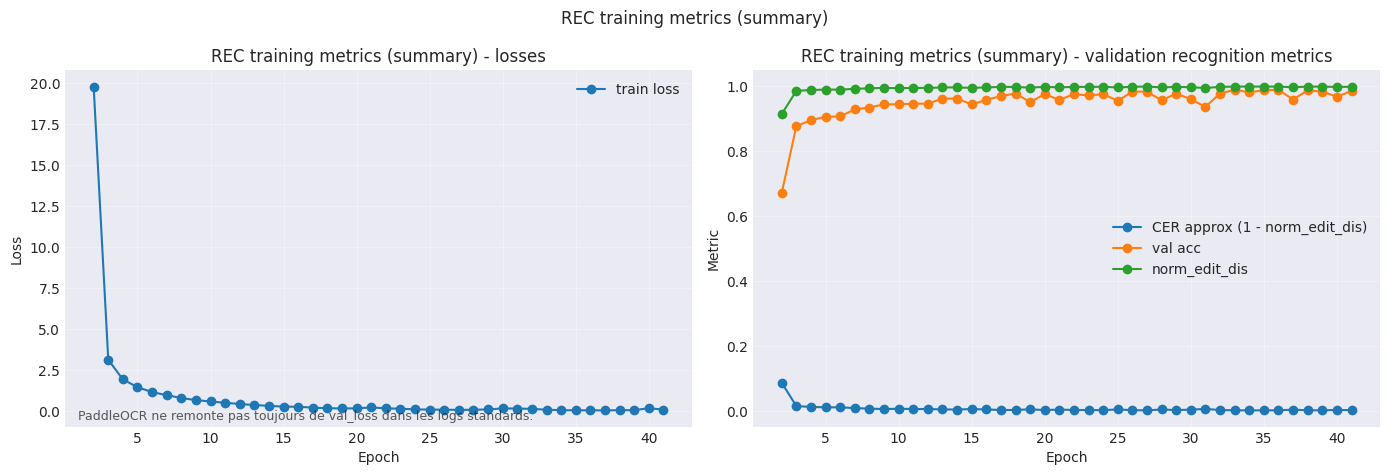

PosixPath('/teamspace/studios/this_studio/workspace_paddleocr_invoice/runs/metrics/rec_epoch_metrics.png')

In [14]:
REC_MODEL_DIR = RUNS_DIR / "rec"
METRICS_DIR = RUNS_DIR / "metrics"
REC_METRICS_CSV = METRICS_DIR / "rec_epoch_metrics.csv"
REC_METRICS_PNG = METRICS_DIR / "rec_epoch_metrics.png"

rec_metrics_df = pd.read_csv(REC_METRICS_CSV)

print("Nombre d'epochs :", len(rec_metrics_df))
print("Best val_acc:", rec_metrics_df["val_acc"].max())
print("Best val_norm_edit_dis:", rec_metrics_df["val_norm_edit_dis"].max())

display(rec_metrics_df)

plot_training_metrics(
    rec_metrics_df,
    "rec",
    "REC training metrics (summary)",
    REC_METRICS_PNG,
    show_inline=True,
)


## 6. Sélection du meilleur checkpoint et export REC

À partir des métriques de validation produites pendant l'entraînement, le notebook sélectionne explicitement le meilleur checkpoint du REC, puis l'exporte au format d'inférence PaddleOCR (`rec_infer`).


### Sélection du meilleur checkpoint REC

Le modèle retenu pour la suite est choisi à partir des métriques de validation produites pendant l'entraînement :

- `val_norm_edit_dis` (plus haut = mieux) ;
- puis `val_acc` comme critère secondaire ;
- puis l'epoch la plus précoce en cas d'égalité.

Ce choix permet de documenter explicitement :
- **quel checkpoint est retenu** ;
- **pourquoi il est retenu** ;
- **quelle preuve chiffrée justifie ce choix**.

Résultat observé sur le run conservé :
- `BEST_REC_EPOCH = 34`
- `BEST_REC_CKPT_PREFIX = /teamspace/studios/this_studio/workspace_paddleocr_invoice/runs/rec/iter_epoch_34`
- `critère principal retenu = val_norm_edit_dis`



In [16]:
# Sélection du meilleur checkpoint REC à partir des métriques de validation
if not REC_METRICS_CSV.exists():
    if not RUN_REC_TRAINING:
        raise FileNotFoundError(
            f"Fichier de métriques introuvable: {REC_METRICS_CSV}. "
            "Relancer l'entraînement REC ou remettre le CSV de métriques dans runs/metrics."
        )
    raise FileNotFoundError(f"Fichier de métriques introuvable: {REC_METRICS_CSV}")

rec_metrics_df = pd.read_csv(REC_METRICS_CSV)
if rec_metrics_df.empty:
    raise RuntimeError("Le fichier de métriques REC est vide.")

rec_metrics_ranked = rec_metrics_df.copy()
numeric_cols = ["train_loss", "val_loss", "val_acc", "val_norm_edit_dis", "val_cer_proxy"]
for col in numeric_cols:
    if col in rec_metrics_ranked.columns:
        rec_metrics_ranked[col] = pd.to_numeric(rec_metrics_ranked[col], errors="coerce")

if rec_metrics_ranked["val_norm_edit_dis"].notna().any():
    best_rec_row = rec_metrics_ranked.sort_values(
        ["val_norm_edit_dis", "val_acc", "epoch"],
        ascending=[False, False, True],
    ).iloc[0]
    best_rec_metric = "val_norm_edit_dis"
elif rec_metrics_ranked["val_acc"].notna().any():
    best_rec_row = rec_metrics_ranked.sort_values(
        ["val_acc", "epoch"],
        ascending=[False, True],
    ).iloc[0]
    best_rec_metric = "val_acc"
else:
    raise RuntimeError("Aucune métrique de validation exploitable pour sélectionner le meilleur checkpoint REC.")

BEST_REC_EPOCH = int(best_rec_row["epoch"])
BEST_REC_CKPT_PREFIX = REC_MODEL_DIR / f"iter_epoch_{BEST_REC_EPOCH}"
BEST_REC_CKPT_EXISTS = BEST_REC_CKPT_PREFIX.with_suffix(".pdparams").exists()

ranking_cols = ["epoch", "train_loss", "val_loss", "val_acc", "val_norm_edit_dis", "val_cer_proxy"]
ranking_cols = [c for c in ranking_cols if c in rec_metrics_ranked.columns]
rec_top_epochs = rec_metrics_ranked.sort_values(
    [best_rec_metric, "epoch"],
    ascending=[False, True],
)[ranking_cols].head(10)

print("Best REC selection metric:", best_rec_metric)
print("BEST_REC_EPOCH:", BEST_REC_EPOCH)
print("BEST_REC_CKPT_PREFIX:", BEST_REC_CKPT_PREFIX)
print("Checkpoint .pdparams exists:", BEST_REC_CKPT_EXISTS)
print("Best row:", best_rec_row[ranking_cols].to_dict())

print("\nTop epochs by validation metric:")
display(rec_top_epochs)

print("\nLast epochs in chronological order:")
display(rec_metrics_ranked.sort_values("epoch")[ranking_cols].tail(min(10, len(rec_metrics_ranked))))


Best REC selection metric: val_norm_edit_dis
BEST_REC_EPOCH: 34
BEST_REC_CKPT_PREFIX: /teamspace/studios/this_studio/workspace_paddleocr_invoice/runs/rec/iter_epoch_34
Checkpoint .pdparams exists: True
Best row: {'epoch': 34.0, 'train_loss': 0.04078434375, 'val_loss': nan, 'val_acc': 0.980469, 'val_norm_edit_dis': 0.998111, 'val_cer_proxy': 0.001889}

Top epochs by validation metric:


,epoch,train_loss,val_loss,val_acc,val_norm_edit_dis,val_cer_proxy
32,34,0.040784,NaN,0.980469,0.998111,0.001889
25,27,0.058329,NaN,0.982422,0.998101,0.001899
34,36,0.032713,NaN,0.988281,0.997987,0.002013
33,35,0.033412,NaN,0.986328,0.997941,0.002059
36,38,0.039294,NaN,0.986328,0.997911,0.002089
31,33,0.070144,NaN,0.988281,0.997853,0.002147
37,39,0.040569,NaN,0.982422,0.997745,0.002255
22,24,0.092253,NaN,0.974609,0.997500,0.002500
24,26,0.072692,NaN,0.982422,0.997444,0.002556
39,41,0.072779,NaN,0.984375,0.997377,0.002623



Last epochs in chronological order:


,epoch,train_loss,val_loss,val_acc,val_norm_edit_dis,val_cer_proxy
30,32,0.118640,NaN,0.976562,0.997083,0.002917
31,33,0.070144,NaN,0.988281,0.997853,0.002147
32,34,0.040784,NaN,0.980469,0.998111,0.001889
33,35,0.033412,NaN,0.986328,0.997941,0.002059
34,36,0.032713,NaN,0.988281,0.997987,0.002013
35,37,0.028239,NaN,0.958055,0.995763,0.004237
36,38,0.039294,NaN,0.986328,0.997911,0.002089
37,39,0.040569,NaN,0.982422,0.997745,0.002255
38,40,0.163111,NaN,0.966797,0.996760,0.003240
39,41,0.072779,NaN,0.984375,0.997377,0.002623


### Export du meilleur checkpoint REC

Une fois le meilleur checkpoint identifié, il est exporté au format d'inférence PaddleOCR (`rec_infer`).

Cet export matérialise la transition entre :
1. le **checkpoint d'entraînement** retenu (`BEST_REC_CKPT_PREFIX`) ;
2. et le **modèle de reconnaissance** effectivement rechargé dans les sections de tests suivantes.

Résultat observé :
- chemin d'export final = `/teamspace/studios/this_studio/workspace_paddleocr_invoice/export/rec_infer`
- mode d'export utilisé = `gpu`



In [17]:
# Export du meilleur checkpoint REC au format d'inférence PaddleOCR
# L'export standard PIR fonctionne sur l'environnement Lightning ;
# ne pas forcer le chemin legacy via Global.export_with_pir=False.
if "BEST_REC_CKPT_PREFIX" not in globals():
    raise RuntimeError("BEST_REC_CKPT_PREFIX introuvable. Exécuter d'abord la cellule de sélection du meilleur checkpoint.")
if not BEST_REC_CKPT_PREFIX.with_suffix(".pdparams").exists():
    raise FileNotFoundError(
        f"Checkpoint REC introuvable: {BEST_REC_CKPT_PREFIX.with_suffix('.pdparams')}"
    )

EXPORT_DIR = WORK_DIR / "export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
REC_INFER_DIR = EXPORT_DIR / "rec_infer"


def build_export_cmd(cfg_path: Path, ckpt_prefix: Path, infer_dir: Path, use_gpu: bool, extra_opts=None):
    cmd = [
        sys.executable,
        str(PADDLEOCR_REPO / "tools/export_model.py"),
        "-c", str(cfg_path),
        "-o",
        f"Global.checkpoints={ckpt_prefix}",
        f"Global.save_inference_dir={infer_dir}",
        f"Global.use_gpu={str(bool(use_gpu))}",
    ]
    if extra_opts:
        cmd.extend(extra_opts)
    return cmd


def export_with_fallback(cfg_path: Path, ckpt_prefix: Path, infer_dir: Path, extra_opts=None):
    cmd_gpu = build_export_cmd(cfg_path, ckpt_prefix, infer_dir, use_gpu=True, extra_opts=extra_opts)
    print("Running export (GPU):\n", " ".join(str(x) for x in cmd_gpu))
    try:
        subprocess.run(cmd_gpu, check=True, cwd=PADDLEOCR_REPO)
        return "gpu"
    except subprocess.CalledProcessError:
        print("GPU export failed; retry on CPU...")

    cmd_cpu = build_export_cmd(cfg_path, ckpt_prefix, infer_dir, use_gpu=False, extra_opts=extra_opts)
    print("Running export (CPU fallback):\n", " ".join(str(x) for x in cmd_cpu))
    subprocess.run(cmd_cpu, check=True, cwd=PADDLEOCR_REPO)
    return "cpu"


rec_extra_opts = []
if CHAR_DICT is not None:
    rec_extra_opts += [f"Global.character_dict_path={CHAR_DICT}"]

rec_export_mode = export_with_fallback(REC_CFG, BEST_REC_CKPT_PREFIX, REC_INFER_DIR, extra_opts=rec_extra_opts)

print("REC_INFER_DIR:", REC_INFER_DIR, f"(exported via {rec_export_mode})")
print("Export source checkpoint:", BEST_REC_CKPT_PREFIX)


Running export (GPU):
 /teamspace/studios/this_studio/.venv/bin/python /teamspace/studios/this_studio/workspace_paddleocr_invoice/tools/export_model.py -c /teamspace/studios/this_studio/workspace_paddleocr_invoice/configs/rec/rec_mv3_none_bilstm_ctc.yml -o Global.checkpoints=/teamspace/studios/this_studio/workspace_paddleocr_invoice/runs/rec/iter_epoch_34 Global.save_inference_dir=/teamspace/studios/this_studio/workspace_paddleocr_invoice/export/rec_infer Global.use_gpu=True Global.character_dict_path=/teamspace/studios/this_studio/workspace_paddleocr_invoice/ppocr/utils/en_dict.txt


/teamspace/studios/this_studio/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Skipping import of the encryption module.


W0416 23:42:53.687665 747079 gpu_resources.cc:116] Please NOTE: device: 0, GPU Compute Capability: 8.9, Driver API Version: 13.0, Runtime API Version: 12.6


[2026/04/16 23:42:53] ppocr INFO: The parameter type is float16, which is converted to float32 when loading
[2026/04/16 23:42:53] ppocr INFO: resume from /teamspace/studios/this_studio/workspace_paddleocr_invoice/runs/rec/iter_epoch_34
[2026/04/16 23:42:53] ppocr INFO: Export inference config file to /teamspace/studios/this_studio/workspace_paddleocr_invoice/export/rec_infer/inference.yml
Skipping import of the encryption module


W0416 23:42:54.423408 747079 eager_utils.cc:3584] Paddle static graph(PIR) not support input out tensor for now!!!!!


[2026/04/16 23:42:55] ppocr INFO: inference model is saved to /teamspace/studios/this_studio/workspace_paddleocr_invoice/export/rec_infer/inference
REC_INFER_DIR: /teamspace/studios/this_studio/workspace_paddleocr_invoice/export/rec_infer (exported via gpu)
Export source checkpoint: /teamspace/studios/this_studio/workspace_paddleocr_invoice/runs/rec/iter_epoch_34


## 7. Évaluation REC seul

Cette section documente **le modèle REC seul**, indépendamment du pipeline facture complète.

Ce qui est évalué ici :
- la convergence du fine-tuning sur les crops texte supervisés ;
- la qualité de reconnaissance sur la validation interne issue de `batch_1` ;
- la cohérence entre la trajectoire d'apprentissage et le checkpoint retenu pour l'export.

Ce qui n'est **pas** évalué ici :
- la qualité de détection sur facture complète ;
- le comportement d'un pipeline OCR bout-en-bout.


### Trajectoire d'apprentissage

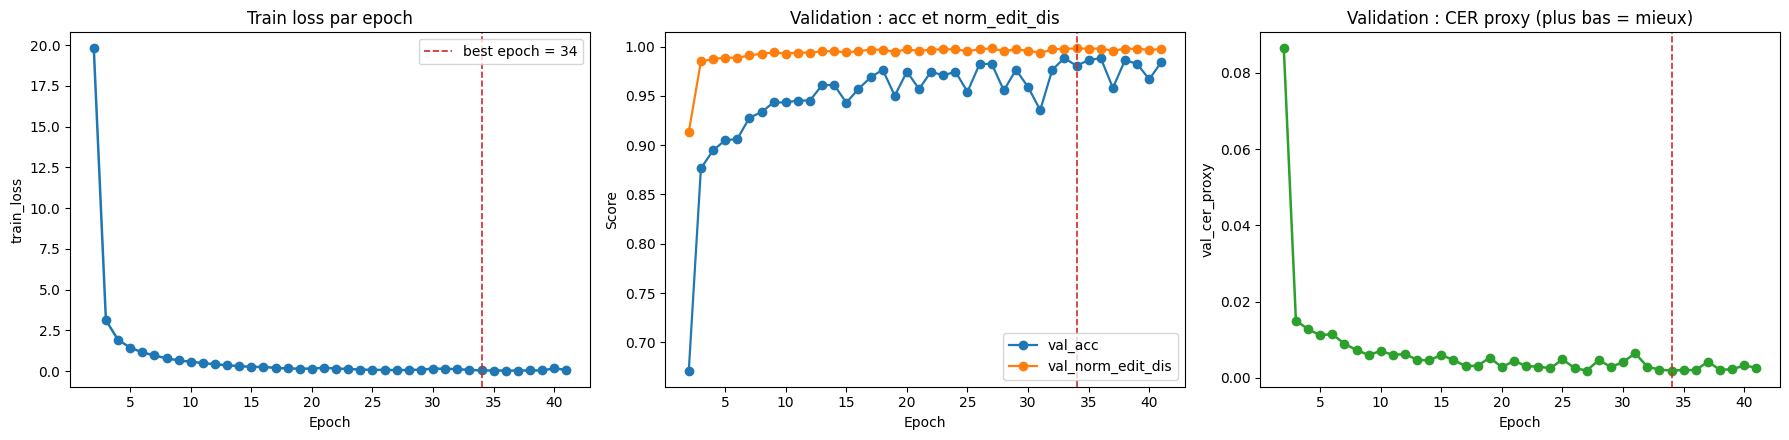

In [ ]:
# Graphiques complémentaires pour documenter la trajectoire d'apprentissage du REC
REC_METRICS_CSV = RUNS_DIR / "metrics" / "rec_epoch_metrics.csv"
rec_metrics_plot_df = pd.read_csv(REC_METRICS_CSV).copy()

for col in ["epoch", "train_loss", "val_acc", "val_norm_edit_dis", "val_cer_proxy"]:
    if col in rec_metrics_plot_df.columns:
        rec_metrics_plot_df[col] = pd.to_numeric(rec_metrics_plot_df[col], errors="coerce")

best_epoch_plot = int(
    rec_metrics_plot_df.sort_values(
        ["val_norm_edit_dis", "val_acc", "epoch"],
        ascending=[False, False, True],
    ).iloc[0]["epoch"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(rec_metrics_plot_df["epoch"], rec_metrics_plot_df["train_loss"], marker="o", linewidth=1.8)
axes[0].axvline(best_epoch_plot, color="tab:red", linestyle="--", linewidth=1.2, label=f"best epoch = {best_epoch_plot}")
axes[0].set_title("Train loss par epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("train_loss")
axes[0].legend(loc="upper right")

axes[1].plot(rec_metrics_plot_df["epoch"], rec_metrics_plot_df["val_acc"], marker="o", linewidth=1.6, label="val_acc")
axes[1].plot(rec_metrics_plot_df["epoch"], rec_metrics_plot_df["val_norm_edit_dis"], marker="o", linewidth=1.6, label="val_norm_edit_dis")
axes[1].axvline(best_epoch_plot, color="tab:red", linestyle="--", linewidth=1.2)
axes[1].set_title("Validation : acc et norm_edit_dis")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend(loc="lower right")

axes[2].plot(rec_metrics_plot_df["epoch"], rec_metrics_plot_df["val_cer_proxy"], marker="o", linewidth=1.8, color="tab:green")
axes[2].axvline(best_epoch_plot, color="tab:red", linestyle="--", linewidth=1.2)
axes[2].set_title("Validation : CER proxy (plus bas = mieux)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("val_cer_proxy")

plt.tight_layout()
plt.show()


Sur le run conservé, le CSV de métriques contient **41 epochs loggés**. La dynamique observée reste cohérente :
- `train_loss` diminue fortement au fil de l'entraînement, avec une baisse marquée sur la seconde moitié du run ;
- `val_acc` monte jusqu'à un niveau très élevé, avec un maximum à `0.988281` ;
- `val_norm_edit_dis` progresse jusqu'à `0.998111`, ce qui correspond à un `cer_proxy` minimal de `0.001889`.

Points clés :
- `best epoch = 34`
- `val_acc max = 0.988281`
- `val_norm_edit_dis max = 0.998111`
- `cer_proxy min = 0.001889`

### Interprétation

La convergence est progressive et reste utile jusque dans les epochs 30+, ce qui justifie le budget retenu. Le fine-tuning apporte un gain net bien avant la fin du run, puis le modèle entre dans une zone de plateau autour des epochs 34 à 36. Le checkpoint 34 est retenu car il maximise la métrique principale de validation (`val_norm_edit_dis`) tout en conservant une `val_acc` très élevée.

### Gestion de l'overfitting

Une légère instabilité apparaît après le meilleur point de validation : certaines dernières epochs gardent de très bonnes métriques, mais d'autres régressent légèrement. Le protocole reste robuste car le modèle final est choisi sur le **meilleur checkpoint validation**, et non sur le dernier epoch. Le split par facture limite en plus le risque de fuite entre entraînement et validation.

### Limite importante

Ces très bonnes métriques internes ne signifient pas pour autant que le pipeline généralise bien sur tout type de facture. Elles reflètent surtout la qualité du REC sur les crops issus du protocole supervisé interne.



#### Note : `val_loss` non disponible dans PaddleOCR

La colonne `val_loss` est `NaN` sur l'ensemble du run. Ce comportement est normal : `train.py` PaddleOCR ne calcule pas de loss de validation par défaut. Il évalue le modèle sur le jeu de validation mais expose uniquement les métriques de reconnaissance (`val_acc`, `val_norm_edit_dis`). La CTC loss n'est loggée que sur le jeu d'entraînement.

La sélection du meilleur checkpoint s'appuie donc exclusivement sur `val_norm_edit_dis` (puis `val_acc` en critère secondaire), ce qui est cohérent avec l'objectif de transcription.

## 8. Évaluation pipeline OCR complet sur facture

Les sections suivantes ne documentent plus le REC seul, mais le comportement d'un pipeline complet sur facture entière :
- préprocessing documentaire partagé (`preprocessing.py`) ;
- détection de zones texte via **RapidOCR** ;
- reconnaissance via le **REC PaddleOCR fine-tuné exporté**.

### 8.1 Réutilisation du preprocessing partagé (NB2)

Le module `preprocessing.py` issu de NB2 est réutilisé dans NB3 comme **source unique de preprocessing facture page entière** pour les parcours d'inférence, les tests qualitatifs et les analyses applicatives.

NB2 et NB3 sont complémentaires :
1. **NB2** documente et justifie le preprocessing documentaire appliqué à la facture entière ;
2. **NB3** prépare les données OCR, fine-tune le REC puis teste le pipeline complet.

Point important : la boucle d'entraînement REC ne consomme pas directement `preprocess_invoice()`. Elle apprend sur des **crops de lignes** générés dans la chaîne supervisée de NB3, puis applique la normalisation interne PaddleOCR (`RecResizeImg`). En revanche, les tests sur facture complète de fin de notebook réutilisent bien `preprocessing.py`.

In [26]:
# Import du module preprocessing.py partagé (source unique NB2)
import sys as _sys
from pathlib import Path as _Path

_nb_dir = _Path().resolve()
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))

try:
    from preprocessing import (
        preprocess_invoice,
        to_grayscale_lab,
        resize_to_width,
        apply_clahe,
        deskew,
        denoise,
        extract_text_line_crops,
    )
    print("preprocessing.py : fonctions importées ->", [
        'preprocess_invoice', 'to_grayscale_lab', 'resize_to_width',
        'apply_clahe', 'deskew', 'denoise', 'extract_text_line_crops',
    ])
except ModuleNotFoundError as exc:
    print(f"preprocessing.py non accessible ({exc}) : les cellules d'inférence utiliseront uniquement l'image brute.")

preprocessing.py : fonctions importées -> ['preprocess_invoice', 'to_grayscale_lab', 'resize_to_width', 'apply_clahe', 'deskew', 'denoise', 'extract_text_line_crops']


### 8.2 Bootstrap de l'inférence locale : export PIR du run courant et initialisation des moteurs
Cette cellule prépare le moteur de reconnaissance PaddleOCR à partir du meilleur checkpoint exporté et initialise RapidOCR pour la détection.


In [15]:
# Bootstrap inférence locale : export PIR du run courant et initialisation des moteurs
if "WORK_DIR" not in globals():
    WORK_DIR = Path("./workspace_paddleocr_invoice").resolve()
if "PADDLEOCR_REPO" not in globals() or PADDLEOCR_REPO is None:
    repo_candidates = [(WORK_DIR / "PaddleOCR").resolve(), WORK_DIR.resolve()]
    PADDLEOCR_REPO = next(
        (p for p in repo_candidates if (p / "tools/infer/predict_system.py").exists()),
        None,
    )
if PADDLEOCR_REPO is None:
    raise FileNotFoundError("Repo PaddleOCR local introuvable pour l'inférence.")

EXPORT_DIR = WORK_DIR / "export"
REC_INFER_DIR = EXPORT_DIR / "rec_infer"
REC_CHAR_DICT = Path(CHAR_DICT) if CHAR_DICT is not None else PADDLEOCR_REPO / "ppocr/utils/en_dict.txt"
INFER_OUTPUT_DIR = WORK_DIR / "inference_outputs"
INFER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Flux retenu pour NB3 : export PaddleOCR standard en PIR.
os.environ["FLAGS_enable_pir_api"] = "1"
required_files = [
    REC_INFER_DIR / "inference.json",
    REC_INFER_DIR / "inference.pdiparams",
    REC_INFER_DIR / "inference.yml",
    REC_CHAR_DICT,
]
missing = [str(p) for p in required_files if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Artefacts d'inférence du run courant manquants :\n- "
        + "\n- ".join(missing)
        + "\nExécuter d'abord la cellule d'export du meilleur checkpoint."
    )

if str(PADDLEOCR_REPO) not in sys.path:
    sys.path.insert(0, str(PADDLEOCR_REPO))

import tools.infer.utility as infer_utility
import tools.infer.predict_rec as predict_rec
from tools.infer.utility import get_rotate_crop_image


def resolve_rec_image_shape(rec_model_dir: Path) -> str:
    cfg = yaml.safe_load((rec_model_dir / "inference.yml").read_text(encoding="utf-8"))
    for op in cfg.get("PreProcess", {}).get("transform_ops", []):
        if "RecResizeImg" in op:
            shape = op["RecResizeImg"].get("image_shape")
            if shape:
                return ",".join(str(v) for v in shape)
    return "3,32,100"


def build_local_infer_args(use_gpu: bool = False):
    parser = infer_utility.init_args()
    args = parser.parse_args([])
    args.rec_algorithm = "CRNN"
    args.use_gpu = bool(use_gpu and USE_GPU_FOR_FINAL_INFERENCE)
    args.enable_mkldnn = False
    args.show_log = False
    args.warmup = False
    args.rec_model_dir = str(REC_INFER_DIR)
    args.rec_char_dict_path = str(REC_CHAR_DICT)
    args.rec_image_shape = resolve_rec_image_shape(REC_INFER_DIR)
    args.rec_batch_num = 12
    args.draw_img_save_dir = str(INFER_OUTPUT_DIR / "draws")
    args.save_log_path = str(INFER_OUTPUT_DIR / "logs")
    args.vis_font_path = str(PADDLEOCR_REPO / "doc/fonts/simfang.ttf")
    return args


LOCAL_INFER_ARGS = build_local_infer_args(use_gpu=USE_GPU_FOR_FINAL_INFERENCE)
rec_recognizer = predict_rec.TextRecognizer(LOCAL_INFER_ARGS)
rapid_detector = RapidOCR()

print("PaddleOCR repo local:", PADDLEOCR_REPO)
print("REC inference dir:", REC_INFER_DIR)
print("REC model file:", REC_INFER_DIR / "inference.json")
print("FLAGS_enable_pir_api:", os.environ["FLAGS_enable_pir_api"])
print("REC character dict:", REC_CHAR_DICT)
print("Detection backend:", "RapidOCR")
print("Note: la reconnaissance utilise le modèle REC exporté du run courant.")

/teamspace/studios/this_studio/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


[2026/04/18 12:52:53] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0
PaddleOCR repo local: /teamspace/studios/this_studio/workspace_paddleocr_invoice
REC inference dir: /teamspace/studios/this_studio/workspace_paddleocr_invoice/export/rec_infer
REC model file: /teamspace/studios/this_studio/workspace_paddleocr_invoice/export/rec_infer/inference.json
FLAGS_enable_pir_api: 1
REC character dict: /teamspace/studios/this_studio/workspace_paddleocr_invoice/ppocr/utils/en_dict.txt
Detection backend: RapidOCR
Note: la reconnaissance utilise le modèle REC exporté du run courant.


### 8.3 Packaging du modèle final
Le meilleur `rec_infer` exporté depuis le run courant est copié dans `models/` à la racine du projet afin de matérialiser le modèle final retenu et de le rendre réutilisable hors du notebook.

In [36]:
# Packaging du modèle final : copie du rec_infer retenu dans models/
FINAL_MODEL_DIR = PROJECT_ROOT / "models" / "PaddleOCR_Invoice_v2"
FINAL_REC_INFER_DIR = FINAL_MODEL_DIR / "rec_infer"
FINAL_REC_INFER_DIR.mkdir(parents=True, exist_ok=True)

packaged_files = []
for src in [
    REC_INFER_DIR / "inference.json",
    REC_INFER_DIR / "inference.pdiparams",
    REC_INFER_DIR / "inference.yml",
    REC_CHAR_DICT,
]:
    if not src.exists():
        raise FileNotFoundError(f"Artefact introuvable pour le packaging final: {src}")
    dst_name = "en_dict.txt" if src == REC_CHAR_DICT else src.name
    dst = FINAL_REC_INFER_DIR / dst_name
    shutil.copy2(src, dst)
    packaged_files.append(dst)

readme_path = FINAL_MODEL_DIR / "README.md"
readme_path.write_text(
    (
        "# PaddleOCR_Invoice_v2\n\n"
        "Modèle REC PaddleOCR fine-tuné sur le corpus facture du notebook NB3.\n\n"
        "Contenu :\n"
        "- `rec_infer/inference.json` : graphe d'inférence exporté (format PIR)\n"
        "- `rec_infer/inference.pdiparams` : poids du modèle\n"
        "- `rec_infer/inference.yml` : configuration d'inférence PaddleOCR\n"
        "- `rec_infer/en_dict.txt` : dictionnaire de caractères utilisé pour le REC\n\n"
        "Provenance :\n"
        "- meilleur checkpoint sélectionné depuis `runs/rec`\n"
        "- export standard PaddleOCR depuis NB3\n"
        "- packaging réalisé automatiquement dans le notebook\n"
    ),
    encoding="utf-8",
)

print("FINAL_MODEL_DIR:", FINAL_MODEL_DIR)
print("FINAL_REC_INFER_DIR:", FINAL_REC_INFER_DIR)
print("Fichiers packagés :")
for f in packaged_files:
    print("-", f)
print("-", readme_path)

FINAL_MODEL_DIR: /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2
FINAL_REC_INFER_DIR: /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2/rec_infer
Fichiers packagés :
- /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2/rec_infer/inference.json
- /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2/rec_infer/inference.pdiparams
- /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2/rec_infer/inference.yml
- /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2/rec_infer/en_dict.txt
- /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2/README.md


### 8.4 Benchmark latence du REC exporté

Mesure de la latence d'inférence du REC fine-tuné sur le meilleur checkpoint exporté (`rec_infer`).

#### Protocole
- Source des crops : jeu de validation NB3 (`prepared_data/rec_images/val/`), échantillon aléatoire de 100 crops (seed=42).
- Moteur : `tools.infer.predict_rec.TextRecognizer` du repo PaddleOCR, artefacts du packaging final `PaddleOCR_Invoice_v2/rec_infer`.
- Warmup : 10 crops hors mesure (évite le coût d'initialisation du graph).
- Deux régimes :
  1. **batch=1** : worst case, 1 crop à la fois (scénario FastAPI `/ocr` par requête courte).
  2. **batch=12** : régime batché retenu en NB3 §9 (rec_batch_num=12), représentatif d'une facture complète.
- Mesures reportées : médiane, moyenne, IQR, p90, fps.
- Hardware : détecté automatiquement (`paddle.device.cuda.get_device_name()` si GPU, sinon CPU).

Les résultats sont sauvegardés dans `models/PaddleOCR_Invoice_v2/latency_benchmark.json` et référencés dans `NB_Comparatif.ipynb`.

In [23]:
# Benchmark latence REC (batch=1 et batch=12) sur le rec_infer packagé
import json
import os
import platform
import random
import sys
import time
from pathlib import Path
import cv2
import numpy as np
import paddle
import yaml

# Chemins
FINAL_MODEL_DIR = PROJECT_ROOT / "models" / "PaddleOCR_Invoice_v2"
FINAL_REC_INFER_DIR = FINAL_MODEL_DIR / "rec_infer"
BENCH_JSON = FINAL_MODEL_DIR / "latency_benchmark.json"
VAL_CROPS_DIR = PREP_DIR / "rec_images" / "val"

assert FINAL_REC_INFER_DIR.exists(), f"REC exporté introuvable: {FINAL_REC_INFER_DIR}"
assert VAL_CROPS_DIR.exists(), f"Crops val introuvables: {VAL_CROPS_DIR}"

# Échantillon
SAMPLE_SIZE = 100
WARMUP = 10
SEED = 42
random.seed(SEED)

all_crops = sorted(str(p) for p in VAL_CROPS_DIR.rglob("*.jpg"))
assert len(all_crops) >= SAMPLE_SIZE + WARMUP, f"Pas assez de crops ({len(all_crops)})"
pool = random.sample(all_crops, SAMPLE_SIZE + WARMUP)
warmup_paths = pool[:WARMUP]
bench_paths = pool[WARMUP:]
print(f"Crops: {len(all_crops)} total, {SAMPLE_SIZE} pour mesure, {WARMUP} warmup")

# Hardware
use_gpu = bool(paddle.device.is_compiled_with_cuda() and paddle.device.cuda.device_count() > 0)
if use_gpu:
    gpu_name = paddle.device.cuda.get_device_name(0)
    hardware = f"GPU: {gpu_name}"
else:
    hardware = f"CPU: {platform.processor() or platform.machine()}"
print("Hardware:", hardware)

# Setup TextRecognizer (via repo PaddleOCR local)
if str(PADDLEOCR_REPO) not in sys.path:
    sys.path.insert(0, str(PADDLEOCR_REPO))
os.environ["FLAGS_enable_pir_api"] = "1"

import tools.infer.predict_rec as predict_rec
import tools.infer.utility as infer_utility


def resolve_shape(rec_dir: Path) -> str:
    cfg = yaml.safe_load((rec_dir / "inference.yml").read_text(encoding="utf-8"))
    for op in cfg.get("PreProcess", {}).get("transform_ops", []):
        if "RecResizeImg" in op:
            s = op["RecResizeImg"].get("image_shape")
            if s:
                return ",".join(str(v) for v in s)
    return "3,32,100"


def build_args(batch_num: int):
    parser = infer_utility.init_args()
    args = parser.parse_args([])
    args.rec_algorithm = "CRNN"
    args.use_gpu = use_gpu
    args.enable_mkldnn = False
    args.show_log = False
    args.warmup = False
    args.rec_model_dir = str(FINAL_REC_INFER_DIR)
    args.rec_char_dict_path = str(FINAL_REC_INFER_DIR / "en_dict.txt")
    args.rec_image_shape = resolve_shape(FINAL_REC_INFER_DIR)
    args.rec_batch_num = batch_num
    return args


def load_imgs(paths):
    return [cv2.imread(p) for p in paths]


def bench_batch(batch_num: int):
    """Mesure la latence par crop en régime batch=batch_num.

    Pour batch=1 : un appel predict() par crop. La latence par crop = temps de l'appel.
    Pour batch>1 : on envoie la totalité du batch en un appel, on divise par la taille du batch.
    Dans les deux cas, on renvoie les latences par crop individuel.
    """
    recognizer = predict_rec.TextRecognizer(build_args(batch_num))
    # warmup
    _ = recognizer(load_imgs(warmup_paths))
    # mesure
    latencies_ms = []
    if batch_num == 1:
        for p in bench_paths:
            img = cv2.imread(p)
            t0 = time.perf_counter()
            _ = recognizer([img])
            latencies_ms.append((time.perf_counter() - t0) * 1000.0)
    else:
        imgs = load_imgs(bench_paths)
        for i in range(0, len(imgs), batch_num):
            chunk = imgs[i:i + batch_num]
            t0 = time.perf_counter()
            _ = recognizer(chunk)
            dt_ms = (time.perf_counter() - t0) * 1000.0
            latencies_ms.extend([dt_ms / len(chunk)] * len(chunk))
    return np.array(latencies_ms)


def stats(lat_ms: np.ndarray) -> dict:
    return {
        "n": int(len(lat_ms)),
        "median_ms_per_crop": float(np.median(lat_ms)),
        "mean_ms_per_crop": float(np.mean(lat_ms)),
        "p90_ms_per_crop": float(np.percentile(lat_ms, 90)),
        "iqr_ms": [float(np.percentile(lat_ms, 25)), float(np.percentile(lat_ms, 75))],
        "fps_from_median": float(1000.0 / np.median(lat_ms)),
    }


print("\n=== Régime batch=1 (worst case, 1 crop par appel) ===")
lat_b1 = bench_batch(1)
stats_b1 = stats(lat_b1)
for k, v in stats_b1.items():
    print(f"  {k}: {v}")

print("\n=== Régime batch=12 (régime NB3 §9, rec_batch_num=12) ===")
lat_b12 = bench_batch(12)
stats_b12 = stats(lat_b12)
for k, v in stats_b12.items():
    print(f"  {k}: {v}")

# Sauvegarde
bench_report = {
    "hardware": hardware,
    "use_gpu": use_gpu,
    "rec_model_dir": str(FINAL_REC_INFER_DIR),
    "sample_size": SAMPLE_SIZE,
    "warmup": WARMUP,
    "seed": SEED,
    "batch_1": stats_b1,
    "batch_12": stats_b12,
    "measured_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
}
BENCH_JSON.parent.mkdir(parents=True, exist_ok=True)
BENCH_JSON.write_text(json.dumps(bench_report, indent=2))
print("\nSauvegardé:", BENCH_JSON)


/teamspace/studios/this_studio/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Crops: 26654 total, 100 pour mesure, 10 warmup
Hardware: GPU: NVIDIA L4

=== Régime batch=1 (worst case, 1 crop par appel) ===
[2026/04/17 11:40:31] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0
  n: 100
  median_ms_per_crop: 16.407950000029814
  mean_ms_per_crop: 22.02774157002068
  p90_ms_per_crop: 34.626678200015704
  iqr_ms: [14.49443999996447, 31.513295750016823]
  fps_from_median: 60.94606577897805

=== Régime batch=12 (régime NB3 §9, rec_batch_num=12) ===
[2026/04/17 11:40:36] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0
  n: 100
  median_ms_per_crop: 3.390199083336635
  mean_ms_per_crop: 3.674441420000676
  p90_ms_per_crop: 3.7402260000097463
  iqr_ms: [3.134555416655379, 3.692112583337348]
  fps_from_median: 294.96792825977633

Sauvegardé: /teamspace/studios/this_studio/models/PaddleOCR_Invoice_v2/latency_benchmark.json


## 9. Tests et inférence
Les sections suivantes documentent les tests exécutés sur le pipeline complet après export et packaging du modèle final.

### 9.1 Fonctions OCR locales
Ces fonctions orchestrent le pipeline de test retenu : préprocessing NB2, détection RapidOCR, puis reconnaissance avec le REC PaddleOCR exporté.


In [16]:
# Fonctions OCR locales : chargement image, détection des lignes, reconnaissance et sauvegarde
def load_invoice_image_for_ocr(image_path: Path, apply_shared_preprocessing: bool = True):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image introuvable: {image_path}")

    if apply_shared_preprocessing and "preprocess_invoice" in globals():
        gray, meta = preprocess_invoice(str(image_path))
        img_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        meta = {"shared_preprocessing": True, **meta}
        return img_bgr, meta

    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise ValueError(f"Impossible de lire : {image_path}")

    return img_bgr, {
        "shared_preprocessing": False,
        "original_size": (img_bgr.shape[1], img_bgr.shape[0]),
        "processed_size": (img_bgr.shape[1], img_bgr.shape[0]),
        "deskew_angle": 0.0,
    }


def build_crop_entries(img_bgr):
    crop_entries = []
    detector_res, _ = rapid_detector(img_bgr)

    for idx, item in enumerate(detector_res or [], 1):
        if not item or len(item) < 1:
            continue
        box = item[0]
        det_text = str(item[1]).strip() if len(item) > 1 else ""
        det_score = float(item[2]) if len(item) > 2 and item[2] is not None else np.nan
        try:
            crop = get_rotate_crop_image(img_bgr, np.asarray(box, dtype="float32"))
        except Exception:
            continue
        if crop is None or getattr(crop, "size", 0) == 0:
            continue
        crop_entries.append(
            {
                "crop_index": idx,
                "detector_text": det_text,
                "detector_score": det_score,
                "detector_box": np.asarray(box).astype(float).round(2).tolist(),
                "crop_bgr": crop,
                "crop_h": int(crop.shape[0]),
                "crop_w": int(crop.shape[1]),
                "crop_source": "rapidocr_box",
            }
        )

    if crop_entries:
        return crop_entries

    if "extract_text_line_crops" in globals():
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        fallback_crops, heights = extract_text_line_crops(gray, return_heights=True)
        for idx, (crop, height) in enumerate(zip(fallback_crops, heights), 1):
            crop_bgr = np.array(crop)[:, :, ::-1].copy()
            crop_entries.append(
                {
                    "crop_index": idx,
                    "detector_text": "",
                    "detector_score": np.nan,
                    "detector_box": None,
                    "crop_bgr": crop_bgr,
                    "crop_h": int(crop_bgr.shape[0]),
                    "crop_w": int(crop_bgr.shape[1]),
                    "line_height_px": int(height),
                    "crop_source": "line_projection_fallback",
                }
            )

    return crop_entries


def run_local_paddleocr(image_path: Path, apply_shared_preprocessing: bool = True):
    img_bgr, preprocess_meta = load_invoice_image_for_ocr(
        image_path,
        apply_shared_preprocessing=apply_shared_preprocessing,
    )

    crop_entries = build_crop_entries(img_bgr)
    crop_images = [entry["crop_bgr"] for entry in crop_entries]
    if crop_images:
        rec_res, rec_elapsed = rec_recognizer(crop_images)
    else:
        rec_res, rec_elapsed = [], 0.0

    rows = []
    for entry, rec in zip(crop_entries, rec_res):
        text = str(rec[0]).strip()
        score = float(rec[1]) if len(rec) > 1 and rec[1] is not None else np.nan
        if not text:
            continue
        rows.append(
            {
                "line_id": entry["crop_index"],
                "text": text,
                "score": score,
                "detector_text": entry.get("detector_text", ""),
                "detector_score": entry.get("detector_score", np.nan),
                "crop_source": entry.get("crop_source", "unknown"),
                "crop_h": entry.get("crop_h"),
                "crop_w": entry.get("crop_w"),
                "line_height_px": entry.get("line_height_px", entry.get("crop_h")),
                "detector_box": entry.get("detector_box"),
            }
        )

    return {
        "image_path": str(Path(image_path).resolve()),
        "df": pd.DataFrame(rows),
        "time_dict": {"rec": rec_elapsed, "all": rec_elapsed},
        "preprocess_meta": preprocess_meta,
        "n_candidate_crops": len(crop_entries),
    }


def print_ocr_summary(result: dict, preview: int = 50):
    df = result["df"]
    scores = df["score"].dropna() if "score" in df else pd.Series(dtype=float)

    print(f"Image: {Path(result['image_path']).name}")
    print("Shared preprocessing:", result["preprocess_meta"].get("shared_preprocessing", False))
    print("Candidate crops:", result.get("n_candidate_crops", len(df)))
    print(f"Nombre de chaines extraites: {len(df)}")
    if len(scores) > 0:
        print(f"Confiance moyenne: {scores.mean():.4f}")
    print("Temps (s):", result["time_dict"])

    print(f"\n--- APERCU ({min(preview, len(df))} premieres lignes) ---")
    for i, text in enumerate(df.get("text", pd.Series(dtype=str)).tolist()[:preview], 1):
        print(f"{i:03d}. {text}")


def save_local_ocr_outputs(result: dict, output_base: Path):
    output_base = Path(output_base)
    output_base.parent.mkdir(parents=True, exist_ok=True)

    df = result["df"]
    txt_path = output_base.with_suffix(".txt")
    csv_path = output_base.with_suffix(".csv")
    json_path = output_base.with_suffix(".json")

    texts = df["text"].tolist() if "text" in df else []
    txt_path.write_text("\n".join(texts), encoding="utf-8")
    df.to_csv(csv_path, index=False)
    json_path.write_text(
        json.dumps(
            {
                "image_path": result["image_path"],
                "preprocess_meta": result["preprocess_meta"],
                "time_dict": result["time_dict"],
                "rows": df.to_dict(orient="records"),
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
    return txt_path, csv_path, json_path


def resolve_ab_image(case_name: str) -> Path:
    # Les chemins A/B sont résolus relativement à PROJECT_ROOT.
    cases = {
        "batch3-0501": [
            PROJECT_ROOT / "Promy_raw/datasets/High-Quality Invoice Images for OCR/batch_3/batch_3/batch3_2/batch3-0501.jpg",
        ],
        "hors_corpus_local": [
            PROJECT_ROOT / "Promy_raw/datasets/invoiceextra.png",
        ],
        "avril2025auchan-local1704202519042029S0C0epagny-1": [
            PROJECT_ROOT / "Promy_raw/datasets/promy_catalog_v1/avril2025auchan-local1704202519042029S0C0epagny-1.jpg",
        ],
    }
    for candidate in cases[case_name]:
        candidate = Path(candidate).resolve()
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Aucune image disponible pour le cas A/B: {case_name}")


def run_ab_case(image_path: Path, output_stem: str | None = None, preview: int = 50):
    result = run_local_paddleocr(image_path, apply_shared_preprocessing=True)
    print_ocr_summary(result, preview=preview)
    out_dir = WORK_DIR / "testsAB_outputs"
    out_dir.mkdir(parents=True, exist_ok=True)
    base = out_dir / (output_stem if output_stem else Path(image_path).stem)
    txt_path, csv_path, json_path = save_local_ocr_outputs(result, base)
    print("\nArtefacts sauvegardés:")
    print("-", txt_path)
    print("-", csv_path)
    print("-", json_path)
    return result

print("Fonctions OCR locales prêtes : run_local_paddleocr, print_ocr_summary, save_local_ocr_outputs, run_ab_case")


Fonctions OCR locales prêtes : run_local_paddleocr, print_ocr_summary, save_local_ocr_outputs, run_ab_case


### 9.2 Test local sur une facture JPG
Premier contrôle lisible du pipeline complet sur une facture entière, avec préprocessing NB2, détection RapidOCR et reconnaissance REC PaddleOCR exportée.

In [17]:
# Test local sur une facture JPG avec le modèle REC exporté du run courant
def _first_image_under(root: Path):
    exts = {".jpg", ".jpeg", ".png"}
    if not root.exists():
        return None
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            return p
    return None


def resolve_test_image():
    candidates = []

    if "TEST_IMAGE" in globals() and TEST_IMAGE:
        candidates.append(Path(TEST_IMAGE))

    candidates += [
        PROJECT_ROOT / "Promy_raw/datasets/High-Quality Invoice Images for OCR/batch_3/batch_3/batch3_2/batch3-0501.jpg",
    ]

    for p in candidates:
        p = Path(p).resolve()
        if p.exists() and p.is_file():
            return p

    if "batch2_images" in globals() and len(batch2_images) > 0:
        return Path(batch2_images[0]).resolve()

    if "batch2_root" in globals() and Path(batch2_root).exists():
        p = _first_image_under(Path(batch2_root))
        if p is not None:
            return p.resolve()

    raise FileNotFoundError(
        "Aucune image de test trouvée. Définis TEST_IMAGE ou vérifie la présence du dataset local."
    )


TEST_IMAGE = resolve_test_image()
print("Image de test utilisée:", TEST_IMAGE)

ocr_result = run_local_paddleocr(TEST_IMAGE, apply_shared_preprocessing=True)
print_ocr_summary(ocr_result, preview=200)

raw_txt_out, raw_csv_out, raw_json_out = save_local_ocr_outputs(
    ocr_result,
    WORK_DIR / "inference_raw_text",
)
print("\nArtefacts sauvegardés:")
print("-", raw_txt_out)
print("-", raw_csv_out)
print("-", raw_json_out)

Image de test utilisée: /teamspace/studios/this_studio/Promy_raw/datasets/High-Quality Invoice Images for OCR/batch_3/batch_3/batch3_2/batch3-0501.jpg


Image: batch3-0501.jpg
Shared preprocessing: False
Candidate crops: 47
Nombre de chaines extraites: 47
Confiance moyenne: 0.9514
Temps (s): {'rec': 1.0656085014343262, 'all': 1.0656085014343262}

--- APERCU (47 premieres lignes) ---
001. Invoice358559
002. Emaill:tbrianbrianbossierdesign.com
003. Call[--623-777-9044
004. Fax102340-908-890
005. ClientInformation
006. ApoLLoMAOHINE8WVELDING
007. Address44-93Street,Edmonton,T6E5Y3
008. Call:+-908-567-0987
009. Fmaill:infoclientdomaincom
010. PaymentDetails
011. Billmount67965
012. BillDateAug23,2023
013. PaymentStatusPaid
014. DeliveryDateug23,2023
015. PurchaseDate:Sept.9,2023
016. ITEM
017. Gluantity
018. UnitPrice
019. SubTotal
020. 3M0579HOOKIT
021. 4
022. S9
023. S36
024. DISCPAD6X/4
025. 520OMarineAdh
026. 4
027. $16
028. $64
029. Sealant/1Og
030. 3M4032/CUrethane
031. 10
032. $55
033. 5550
034. FoamTape
035. 3M47YellowVinyl
036. 5
037. 55
038. $25
039. Tape
040. 3MT074Hang Tabs
041. 6
042. 526
043. S156
044. Clearx2.
045. Totalmoun

### 9.3 Validation qualitative locale sur 300 factures non annotées du dataset

Cette section documente une **validation qualitative pipeline**, pas une validation supervisée stricte.

Résultats observés sur `batch_2` :
- nombre moyen de segments détectés par facture = `40.61`
- confiance moyenne du REC = `0.9601`
- temps moyen par facture = `0.0845 s`
- principaux cas qui passent bien = factures proches du corpus d'entraînement, avec lignes de texte régulières, segmentation stable et champs documentaires lisibles
- principaux cas d'échec observés = documents plus atypiques, lignes très denses ou mises en page moins structurées, où la détection reste correcte mais la reconnaissance se dégrade localement

### Lecture critique

Cette validation qualitative ne montre pas un OCR robuste multi-formats, mais plutôt un pipeline **correct sur des cas proches du domaine appris**. La confiance moyenne élevée ne suffit pas à conclure à une bonne qualité métier : elle coexiste avec des sorties parfois bruitées, surtout quand la structure du document s'éloigne du corpus d'entraînement. Le résultat doit donc être lu comme un indicateur de faisabilité, pas comme une validation finale de production.



In [18]:
# Validation qualitative non annotee sur batch_2 (modèle REC exporté du run courant)
if len(batch2_images) == 0:
    raise RuntimeError("Aucune image trouvee dans batch_2 pour validation qualitative.")

rows = []
max_images = min(BATCH2_MAX_IMAGES, len(batch2_images))
for img_path in tqdm(batch2_images[:max_images], desc="Batch2 qualitative validation"):
    result = run_local_paddleocr(Path(img_path), apply_shared_preprocessing=True)
    df = result["df"]
    texts = df["text"].tolist() if "text" in df else []
    confs = df["score"].dropna() if "score" in df else pd.Series(dtype=float)

    rows.append(
        {
            "image_path": str(img_path),
            "n_texts": len(texts),
            "mean_conf": float(confs.mean()) if len(confs) > 0 else np.nan,
            "det_time_s": float(result["time_dict"].get("det", np.nan)),
            "rec_time_s": float(result["time_dict"].get("rec", np.nan)),
            "all_time_s": float(result["time_dict"].get("all", np.nan)),
            "shared_preprocessing": bool(result["preprocess_meta"].get("shared_preprocessing", False)),
            "deskew_angle": float(result["preprocess_meta"].get("deskew_angle", 0.0)),
            "raw_text": " | ".join(texts),
        }
    )

val_df = pd.DataFrame(rows)
val_csv = WORK_DIR / "batch2_unlabeled_validation.csv"
val_df.to_csv(val_csv, index=False)

print("Validation qualitative batch_2 terminee")
print("Images traitees:", len(val_df))
print("Moyenne n_texts:", val_df["n_texts"].mean() if len(val_df) else 0)
print("Moyenne confidence:", val_df["mean_conf"].mean(skipna=True) if len(val_df) else float("nan"))
print("Temps moyen total (s):", val_df["all_time_s"].mean(skipna=True) if len(val_df) else float("nan"))
print("CSV resultat:", val_csv)
val_df.head(10)


Batch2 qualitative validation:   0%|          | 0/300 [00:00<?, ?it/s]

Validation qualitative batch_2 terminee
Images traitees: 300
Moyenne n_texts: 40.60333333333333
Moyenne confidence: 0.958050366809252
Temps moyen total (s): 0.08464744806289673
CSV resultat: /teamspace/studios/this_studio/workspace_paddleocr_invoice/batch2_unlabeled_validation.csv


,image_path,n_texts,mean_conf,det_time_s,rec_time_s,all_time_s,shared_preprocessing,deskew_angle,raw_text
0,/teamspace/studios/this_studio/Promy_raw/datas...,37,0.967822,NaN,0.175044,0.175044,False,0.0,Invoice | acctN8CpCGmFZCxllDx | Invoicenumlber...
1,/teamspace/studios/this_studio/Promy_raw/datas...,2,0.923501,NaN,0.057572,0.057572,False,0.0,"64909782624USD dueNov,1,2023 | PageMof"
2,/teamspace/studios/this_studio/Promy_raw/datas...,56,0.964282,NaN,0.146208,0.146208,False,0.0,Invoice | acctN8CpCGmFzOll | Invoicenumber | 9...
3,/teamspace/studios/this_studio/Promy_raw/datas...,37,0.961573,NaN,0.105142,0.105142,False,0.0,EastOliffsupplyo.Ltd | 42Lindsayvenue | Dorval...
4,/teamspace/studios/this_studio/Promy_raw/datas...,37,0.963356,NaN,0.091524,0.091524,False,0.0,BLUEBNDMEDI | 675KingStreetWVestSuite30 | Toro...
5,/teamspace/studios/this_studio/Promy_raw/datas...,38,0.968197,NaN,0.100690,0.100690,False,0.0,"AcmeMoulesutils | 567O,ruFullum | Montreal | F..."
6,/teamspace/studios/this_studio/Promy_raw/datas...,38,0.952389,NaN,0.093127,0.093127,False,0.0,DYNPLLTD | 38OPASSMOREAVE | CRBOROUGM | FloraL...
7,/teamspace/studios/this_studio/Promy_raw/datas...,37,0.963415,NaN,0.102934,0.102934,False,0.0,"BombardierAerospacePlant | 80O,boulMarcel-Laur..."
8,/teamspace/studios/this_studio/Promy_raw/datas...,37,0.967571,NaN,0.077475,0.077475,False,0.0,NsE-AutomatechInc | 790boul.Industriel | Granb...
9,/teamspace/studios/this_studio/Promy_raw/datas...,38,0.967660,NaN,0.091789,0.091789,False,0.0,Carstar | 685St-Urbain | Qutremont | FloraLand...


### 9.4 Tests A/B

Ces cas complètent la validation qualitative en observant le pipeline complet sur quelques factures choisies.

Résultats observés :
- cas 1 : `batch3-0501.jpg` -> bon comportement global sur une facture proche du corpus, `47` segments extraits, confiance moyenne `0.9457`, texte globalement lisible malgré quelques erreurs de caractères
- cas 2 : `invoiceextra.png` -> forte dégradation hors corpus, `47` segments extraits mais confiance moyenne seulement `0.7607`, nombreuses lignes largement illisibles
- cas 3 : `avril2025auchan-local1704202519042029S0C0epagny-1.jpg` -> comportement intermédiaire sur un catalogue / ticket visuellement dense, `90` segments extraits, confiance moyenne `0.8811`, mais beaucoup d'erreurs OCR sur les libellés et les montants
- enseignement principal sur la robustesse du pipeline = le pipeline fonctionne bien sur des factures proches du domaine appris, mais perd nettement en qualité dès que la structure documentaire s'éloigne du corpus d'entraînement

### Ce que montrent réellement ces tests

Le problème n'est pas seulement un « template unique », même si l'homogénéité du corpus joue un rôle important. La baisse de qualité provient vraisemblablement d'un ensemble de facteurs :
- corpus d'entraînement trop homogène et peu varié en mises en page ;
- pseudo-labels bruités hérités du teacher OCR ;
- détection non adaptée au domaine, puisque seul le REC a été fine-tuné ;
- dictionnaire `en_dict.txt` limité pour certains contenus FR ou bruités ;
- absence de post-traitement métier pour corriger les montants, dates, fournisseurs ou libellés attendus.

En pratique, le modèle obtenu est donc **spécialisé sur un sous-domaine proche du corpus d'apprentissage**, mais reste fragile hors distribution.



In [19]:
# Test A/B - batch3-0501.jpg

image_path = resolve_ab_image("batch3-0501")
print("Image utilisée:", image_path)
ab_result_batch3 = run_ab_case(image_path, output_stem="batch3-0501", preview=50)


Image utilisée: /teamspace/studios/this_studio/Promy_raw/datasets/High-Quality Invoice Images for OCR/batch_3/batch_3/batch3_2/batch3-0501.jpg


Image: batch3-0501.jpg
Shared preprocessing: False
Candidate crops: 47
Nombre de chaines extraites: 47
Confiance moyenne: 0.9514
Temps (s): {'rec': 0.06750679016113281, 'all': 0.06750679016113281}

--- APERCU (47 premieres lignes) ---
001. Invoice358559
002. Emaill:tbrianbrianbossierdesign.com
003. Call[--623-777-9044
004. Fax102340-908-890
005. ClientInformation
006. ApoLLoMAOHINE8WVELDING
007. Address44-93Street,Edmonton,T6E5Y3
008. Call:+-908-567-0987
009. Fmaill:infoclientdomaincom
010. PaymentDetails
011. Billmount67965
012. BillDateAug23,2023
013. PaymentStatusPaid
014. DeliveryDateug23,2023
015. PurchaseDate:Sept.9,2023
016. ITEM
017. Gluantity
018. UnitPrice
019. SubTotal
020. 3M0579HOOKIT
021. 4
022. S9
023. S36
024. DISCPAD6X/4
025. 520OMarineAdh
026. 4
027. $16
028. $64
029. Sealant/1Og
030. 3M4032/CUrethane
031. 10
032. $55
033. 5550
034. FoamTape
035. 3M47YellowVinyl
036. 5
037. 55
038. $25
039. Tape
040. 3MT074Hang Tabs
041. 6
042. 526
043. S156
044. Clearx2.
045. Totalmo

In [20]:
# Test A/B - hors corpus local

image_path = resolve_ab_image("hors_corpus_local")
print("Image utilisée:", image_path)
ab_result_hors_corpus = run_ab_case(image_path, output_stem="hors_corpus_local", preview=50)


Image utilisée: /teamspace/studios/this_studio/Promy_raw/datasets/invoiceextra.png
Image: invoiceextra.png
Shared preprocessing: False
Candidate crops: 45
Nombre de chaines extraites: 45
Confiance moyenne: 0.7455
Temps (s): {'rec': 0.09249067306518555, 'all': 0.09249067306518555}

--- APERCU (45 premieres lignes) ---
001. DrearwiseReality
002. INV0ICE
003. Drecsarm Biligp.
004. .5ziNMug uewararrod HAtoreyo, Mpastruritey, K zc iA:5
005. (TZ3/45 -78TI(TZ3/4567ER
006. Iyvo c t,r
007. rvelec tyeudckredkCl re,surrkedercoetitektcirmn
008. (atWte .42S,2-
009. Tec
010. Twrmre i a z pen wr tvzS
011. Fire A MMunryclth
012. Ctrua rye irourp
013. BPPucIkc lw
014. S mr, (Frarbcitiechv, c uaA 5. iz X/
015. CluesitoynmweiriIl D IiMIkow&.0/5"'P
016. Noxcaitlion
017. (PkaryniXarnk itkt rit
018. Ourn idh tin
019. crisut ino ucHt,vialr
020. ""MLMF
021. ut ior riccie iP
022. TEo
023. MMlcoynmit he
024. dxescar pt lwon)
025. H oAxuarlLy IRlas'te
026. Llne totall
027. "tanms-aucit kckm ClkbxordllinsaitKkown

In [21]:
# Test A/B - avril2025auchan-local1704202519042029S0C0epagny-1.jpg

image_path = resolve_ab_image("avril2025auchan-local1704202519042029S0C0epagny-1")
print("Image utilisée:", image_path)
ab_result_auchan = run_ab_case(
    image_path,
    output_stem="avril2025auchan-local1704202519042029S0C0epagny-1",
    preview=50,
)


Image utilisée: /teamspace/studios/this_studio/Promy_raw/datasets/promy_catalog_v1/avril2025auchan-local1704202519042029S0C0epagny-1.jpg


Image: avril2025auchan-local1704202519042029S0C0epagny-1.jpg
Shared preprocessing: False
Candidate crops: 97
Nombre de chaines extraites: 97
Confiance moyenne: 0.8646
Temps (s): {'rec': 0.19373703002929688, 'all': 0.19373703002929688}

--- APERCU (50 premieres lignes) ---
001. 'gBoe-,igr
002. ..XBP#"PS MRR.LD
003. Dujeudi17ausamedi19avrill2025
004. LUNDI2
005. Atlontique NordEst
006. AitlLoua itiqQul e
007. 'Noydt
008. EFRANGE
009. Uu
010. U
011. Soi3
012. Lekg
013. Lekg
014. 229
015. 29
016. 8apor tion de10Og
017. $9
018. Lekg
019. AGNEAUFRNCiS
020. DOSDECABILLAUD
021. N0IXDESAINT-3cQUES
022. 24
023. KPectenmaxlmus)
024. Atlontique NordEst
025. Pechiees eng
026. Elev e .en
027. AGNEAIUFRANCaIS
028. UU
029. GIGOT-'*ENIERAVECoS
030. Arotirx
031. Fia lboricquxesie icd a insi rhioys
032. Ateliers
033. Pocourivre ize inh&oun ibities
034. Lekg
035. U
036. 17
037. Lax
038. Uv
039. 255
040. 1.
041. QUEUEDELOTTE
042. desromidu
043. 10
044. 4PAVESDESAUMoN
045. Lapiecede500ga2kg
046. timomoa id 

## 9. Résumé

- **Évaluation REC seul** : le fine-tuning est jugé à partir des métriques de validation internes (`val_norm_edit_dis`, `val_acc`) et du graphique d'entraînement.
- **Sélection du modèle retenu** : le meilleur checkpoint est choisi explicitement puis exporté au format d'inférence PaddleOCR.
- **Évaluation pipeline complet** : les tests facture entière combinent **RapidOCR (backend CPU par défaut) pour la détection** et **REC PaddleOCR fine-tuné** pour la reconnaissance.
- **Synthèse du run conservé** :
  - meilleur epoch = `34`
  - meilleure métrique validation = `val_norm_edit_dis = 0.998111`
  - temps d'entraînement observé = `~29 min sur Lightning L4`
  - résultat du test JPG = `47 segments, confiance moyenne 0.9457, sortie globalement lisible`
  - synthèse batch_2 = `300 factures traitées, 40.61 segments/facture, confiance moyenne 0.9601`
  - synthèse A/B = `bon sur facture proche du corpus, moyen sur document dense, faible hors corpus`

### Conclusion critique

Le notebook valide bien la faisabilité du fine-tuning REC et la capacité à construire un pipeline OCR complet autour du modèle exporté. En revanche, les tests de généralisation montrent que le système reste **fortement dépendant du domaine appris**. Les performances internes sont excellentes, mais la robustesse chute sur des documents plus éloignés du corpus d'entraînement. Le résultat obtenu doit donc être présenté comme un **prototype spécialisé**, pas encore comme un OCR facture générique prêt à l'usage en production.

### Pistes d'amélioration

- diversifier le corpus avec davantage de fournisseurs, de scans et de mises en page ;
- introduire un sous-ensemble annoté manuellement pour réduire le bruit des pseudo-labels ;
- comparer ou adapter explicitement le module de détection, et pas seulement le REC ;
- élargir le dictionnaire de caractères au domaine réel visé ;
- ajouter un post-traitement métier pour corriger et structurer les sorties OCR.



### Risques et limites
- **Dataset single-source** : batch_1 est un corpus homogène. La performance en production dépendra de la variabilité des factures réelles.
- **Language model = English dict** : REC entraîné avec `en_dict.txt`. Ce choix est cohérent avec le corpus Kaggle, qui est un dataset anglophone (factures US/UK, polices standards, chiffres et symboles monétaires anglais). En conséquence, les accents et caractères spécifiques au français (é, è, ê, à, ç…) ne sont pas dans le vocabulaire du modèle. Pour une généralisation aux factures françaises, la prochaine itération devra utiliser un dictionnaire FR (`fr_dict.txt` ou dictionnaire personnalisé) et un corpus d'entraînement incluant des documents en français.
- **Pas de post-traitement métier** : le pipeline actuel produit du texte brut, pas encore une structuration exhaustive des champs facture.
- **Confidentialité** : une facture peut contenir des noms, adresses, identifiants fiscaux et montants. Un usage production implique contrôle d'accès, journalisation et politique de rétention.
